### Préparation : Importation des données et des librairies

In [50]:
### Importation des librairies ###


import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import gc
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import xgboost as xgb
import time

In [51]:
### Importation de la base ###


# Importation
gdf = gpd.read_file('data/processed/jointure_meteo_swi_argile_nearest.gpkg')

# Affichage
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry
0,3834,829935,6712934,1960-12-01,0.989,20.3,48.4,0.209677,2.754839,3.645226,...,0.309710,0.010903,-7.4,9.9,1960,Moyen,2.0,21,0.000000,POINT (779999.389 2280998.516)
1,9001,506479,6268054,1960-10-01,0.557,0.0,150.0,11.406452,1.974194,6.958161,...,0.298871,0.000000,1.5,22.2,1960,Fort,3.0,32,0.000000,POINT (459998.894 1832997.625)
2,9009,570407,6267522,1960-10-01,0.281,0.0,107.6,12.200000,3.241935,7.263516,...,0.282000,0.000000,0.9,22.5,1960,Moyen,2.0,31,0.000000,POINT (523999.225 1832997.246)
3,7123,667777,6442533,1960-01-01,1.132,34.9,153.8,-1.145161,2.458065,3.327548,...,0.304548,0.024452,-16.2,10.0,1960,Faible,1.0,15,0.000000,POINT (619999.329 2008998.82)
4,7154,915528,6440427,1960-01-01,1.055,68.0,50.0,-1.219355,1.864516,3.127871,...,0.305935,0.022806,-14.3,11.0,1960,Faible,1.0,38,0.000000,POINT (867999.111 2008998.974)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-11-01,0.486,0.0,45.3,11.563333,2.510000,7.423633,...,0.191400,0.000000,0.3,20.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005176,7245,363949,6429068,2024-12-01,0.695,0.0,72.5,8.048387,2.909677,5.864935,...,0.206065,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005177,7245,363949,6429068,2024-05-01,0.770,0.0,94.9,15.264516,2.796774,8.711000,...,0.191290,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005178,7245,363949,6429068,2024-10-01,0.438,0.0,75.0,15.170968,2.187097,9.467452,...,0.193871,0.000000,6.5,24.0,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)


# Modélisation du SWI uniforme

In [52]:
### Affichage de la liste des variables ###


list(gdf.columns)

['NUMERO',
 'LAMBX',
 'LAMBY',
 'DATE',
 'SWI_UNIF_MENS',
 'PRENEI',
 'PRELIQ',
 'T',
 'FF',
 'Q',
 'DLI',
 'SSI',
 'HU',
 'EVAP',
 'ETP',
 'PE',
 'SWI',
 'SSWI_10J',
 'DRAINC',
 'RUNC',
 'RESR_NEIGE',
 'RESR_NEIGE6',
 'HTEURNEIGE',
 'HTEURNEIGE6',
 'HTEURNEIGEX',
 'SNOW_FRAC',
 'ECOULEMENT',
 'WG_RACINE',
 'WGI_RACINE',
 'TINF_H',
 'TSUP_H',
 'YEAR',
 'ALEA',
 'NIVEAU',
 'DPT',
 'dist_to_argile',
 'geometry']

In [53]:
### Optimisation de la mémoire : conversion des float64 en float32 ###


# Sélection des colonnes de type float64
cols_float = gdf.select_dtypes(include=['float64']).columns

# Conversion en float32
gdf[cols_float] = gdf[cols_float].astype('float32')

gc.collect()

0

In [54]:
### Isolement de la variable de SWI uniforme mensuel (y) et des variables météorologiques ###


# Variable de SWI uniforme mensuel
y = gdf["SWI_UNIF_MENS"]

# Variables météorologiques
meteo_vars = [
    "T", "Q", "FF",
    "PRENEI", "PRELIQ",
    "SSI", "DLI", "ETP", "PE",
    "RESR_NEIGE", "RESR_NEIGE6",
    "HTEURNEIGE", "HTEURNEIGE6", "HTEURNEIGEX",
    "SNOW_FRAC", "ECOULEMENT",
    "TINF_H", "TSUP_H",
    "NIVEAU", "dist_to_argile"
]

Nous ne sélectionnons pas les variables WG_RACINE et WGI_RACINE car le SWI les utilise dans son calcul, et donc ces variables pourraient biaiser les résultats du modèle.

De plus, nous n'incluons pas les variables EVAP, DRAINC et RUNC qui sont les variables d'évaportation, de drainage et de ruissellement, car elles sont une conséquence du niveau d'humidité SWI et pourraient également biaiser les résultats du modèle.

### Premier enrichissement de la base

In [55]:
### Ajout du cosinus et du sinus à partir du mois ###


# Copie du dataframe
gdf = gdf.copy()

# Extraction du mois
gdf["month"] = gdf["DATE"].dt.month

# Calcul du sinus et du cosinus à partir du mois pour capturer la saisonnalité
gdf["sin_month"] = np.sin(2 * np.pi * gdf["month"] / 12)
gdf["cos_month"] = np.cos(2 * np.pi * gdf["month"] / 12)

# Coordonnées x et y des points
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

# Modèles sans temporalité

### Bases d'entraînement et de test sans variables de lag, diff et cumul

In [56]:
### Dataframes des variables explicatives X et de la variable cible Y ###


# Liste des variables explicatives
X_cols = (
    meteo_vars +
    ["sin_month", "cos_month", "x", "y"]
)

In [57]:
### Séparation des données en bases d'entraînement et de test ###


# Bases d'entraînement et de test
train = gdf[gdf["DATE"] < "2018-01-01"]
test  = gdf[gdf["DATE"] >= "2018-01-01"]

# X et y d'entraînement
X_train = train[X_cols]
y_train = train["SWI_UNIF_MENS"]

# X et y de test
X_test = test[X_cols]
y_test = test["SWI_UNIF_MENS"]

# Création de masques pour le découpage de la base d'entraînement
masque_train_train = gdf["DATE"] < "2017-01-01"
masque_val = (gdf["DATE"] >= "2017-01-01") & (gdf["DATE"] < "2018-01-01")

# Dates uniques de la base de test
dates_test = np.sort(gdf[gdf["DATE"] >= "2018-01-01"]['DATE'].unique())

### Premier modèle : Régression Ridge

In [58]:
### Création du modèle de régression Ridge ###


model_ridge = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=42))
    ]
)

In [59]:
# Prédiction avec le modèle et évaluation de la performance ###


# Entraînement du modèle
model_ridge.fit(X_train, y_train)

# Prédiction sur la base de test
y_pred = model_ridge.predict(X_test)

# Affichage des métriques de performance
print("Coefficients du modèle :", model_ridge.named_steps['reg'].coef_)
print("Intercept du modèle :", model_ridge.named_steps['reg'].intercept_)
print("R² (train) :", model_ridge.score(X_train, y_train))
print("R² (test) :", model_ridge.score(X_test, y_test))
print("RMSE (train) :", np.sqrt(metrics.mean_squared_error(y_train, model_ridge.predict(X_train))))
print("RMSE (test) :", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Coefficients du modèle : [-1.87637889e-01  1.22960127e-01 -2.66173126e-02  1.35101506e-01
  3.00257637e-01 -1.11555007e-01 -5.34234467e-02  2.52605717e-02
 -2.86512761e-01 -2.82782268e+00  2.88469933e+00 -1.17039535e+00
  1.08251885e+00  2.41574578e-02 -1.21320304e-02 -4.69707212e-03
  3.18371512e-02 -5.33591186e-02 -1.41135884e-02 -3.34798901e-03
  1.78822116e-01  1.80499855e-02  2.55524877e-03  1.30474952e-02]
Intercept du modèle : 0.617350126279908
R² (train) : 0.7741976746180796
R² (test) : 0.795202335504797
RMSE (train) : 0.15460353563069112
RMSE (test) : 0.15442128698100044


In [60]:
y_test

6250776    0.639
6250777    0.081
6250778    1.096
6250779    0.210
6250780    1.038
           ...  
7005175    0.486
7005176    0.695
7005177    0.770
7005178    0.438
7005179    0.991
Name: SWI_UNIF_MENS, Length: 754404, dtype: float32

In [61]:
y_pred

array([0.81238671, 0.22139059, 1.12696813, ..., 0.67457818, 0.32953247,
       0.88863152], shape=(754404,))

### Deuxième modèle : Random Forest

In [62]:
### Création, entraînement, prédiction et évaluation du modèle Random Forest ###


# Paramètres du modèle
rf_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 8,
    min_samples_leaf = 50,
    max_samples = 0.5,
    n_jobs = -1,
    random_state = 42,
    verbose = 2
)


# Entraînement du modèle

# Texte de démarrage
print("Démarrage de l'entraînement Random Forest")

# Début du chronomètre
start_time = time.time()

# Entraînement du modèle
rf_model.fit(X_train, y_train)

# Durée d'exécution
duration = time.time() - start_time

# Affichage de la durée
print(f"Entraînement terminé en {duration/60:.1f} minutes.")


# Prédiction et évaluation

print("Calcul des prédictions...")

# Prédictions
preds_rf = rf_model.predict(X_test)

# Calcul de la RMSE
rmse_rf = metrics.root_mean_squared_error(y_test, preds_rf)

# Affichage de la RMSE
print(f"RMSE Random Forest : {rmse_rf:.4f}")

# Calcul du R carré
r2_rf = metrics.r2_score(y_test, preds_rf)

# Affichage du R carré
print(f"R² Random Forest : {r2_rf:.4f}")

Démarrage de l'entraînement Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


building tree 1 of 100building tree 2 of 100
building tree 3 of 100

building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   49.5s


building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100building tree 58 of 100

building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.4min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s


Entraînement terminé en 5.4 minutes.
Calcul des prédictions...
RMSE Random Forest : 0.1566
R² Random Forest : 0.7893


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


### Troisième modèle : XGBoost

C:\Users\elric\AppData\Local\Temp\ipykernel_8164\688414560.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_train = X_train[masque_train_train]
C:\Users\elric\AppData\Local\Temp\ipykernel_8164\688414560.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val = X_train[masque_val]


Lancement de l'entraînement...
[0]	validation_0-rmse:0.31387	validation_1-rmse:0.31857
[50]	validation_0-rmse:0.15405	validation_1-rmse:0.17178
[100]	validation_0-rmse:0.14304	validation_1-rmse:0.16488
[150]	validation_0-rmse:0.13879	validation_1-rmse:0.16243
[200]	validation_0-rmse:0.13538	validation_1-rmse:0.16108
[250]	validation_0-rmse:0.13307	validation_1-rmse:0.16018
[300]	validation_0-rmse:0.13135	validation_1-rmse:0.15924
[350]	validation_0-rmse:0.12988	validation_1-rmse:0.15864
[400]	validation_0-rmse:0.12856	validation_1-rmse:0.15831
[450]	validation_0-rmse:0.12752	validation_1-rmse:0.15774
[500]	validation_0-rmse:0.12645	validation_1-rmse:0.15707
[550]	validation_0-rmse:0.12551	validation_1-rmse:0.15665
[600]	validation_0-rmse:0.12464	validation_1-rmse:0.15599
[650]	validation_0-rmse:0.12384	validation_1-rmse:0.15552
[700]	validation_0-rmse:0.12308	validation_1-rmse:0.15490
[750]	validation_0-rmse:0.12238	validation_1-rmse:0.15423
[800]	validation_0-rmse:0.12173	validation_1

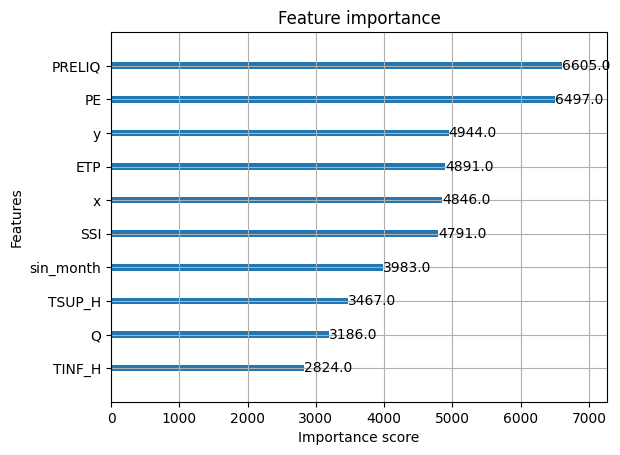

In [63]:
### Modèle de XGBoost ###


# Préparation au XGBoost

# Découpage de X_train et y_train en sous-ensembles d'apprentissage et de validation
X_train_train = X_train[masque_train_train]
y_train_train = y_train[masque_train_train]
X_val = X_train[masque_val]
y_val = y_train[masque_val]

# Paramètres du modèle XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 5,
    tree_method = 'hist',
    n_jobs = -1,
    random_state = 42,
    early_stopping_rounds = 50,
    subsample = 0.7,
    min_child_weight = 50,
)


# Entraînement

# Texte de démarrage
print("Lancement de l'entraînement...")

# Entraînement du modèle
model_xgb.fit(
    X_train, y_train,
    eval_set = [(X_train_train, y_train_train), (X_val, y_val)],
    verbose = 50 
)


# Prédiction et évaluation sur l'échantillon de validation

# Calcul des prédictions
preds_val = model_xgb.predict(X_val)

# Calcul de la RMSE
rmse_val = metrics.root_mean_squared_error(y_val, preds_val)

# Affichage de la RMSE sur l'échantillon de validation
print(f"RMSE Finale : {rmse_val:.4f}")

# Graphique des importances des variables
xgb.plot_importance(model_xgb, max_num_features=10)
plt.show()

In [64]:
### Prédiction avec le XGBoost ###


# Prédiction sur la base de test
preds_test_xgb = model_xgb.predict(X_test)
rmse_test_xgb = metrics.root_mean_squared_error(y_test, preds_test_xgb)

# Affichage des résultats
print("R² (train) :", model_xgb.score(X_train, y_train))
print("R² (test) :", model_xgb.score(X_test, y_test))
print("RMSE (train) :", metrics.root_mean_squared_error(y_train, model_xgb.predict(X_train)))
print("RMSE (test) :", rmse_test_xgb)

R² (train) : 0.8802480101585388
R² (test) : 0.8606747388839722
RMSE (train) : 0.11258916556835175
RMSE (test) : 0.12736776471138


In [65]:
### Suppression des bases d'entraînement et de test pour libérer de la mémoire ###

del train, test, X_train, X_train_train, X_val, X_test, y_train, y_train_train, y_val, y_test
gc.collect()

4637

# Modèles avec temporalité

### Préparation de variables de lag, diff et cumul

In [66]:
### Ajout d'une colonne de SWI des deux périodes précédentes (lag 1 et lag 2) ###


# Tri de la base par point de la grille puis par date
gdf = gdf.sort_values(by=["NUMERO", "DATE"])

# Ajout de la colonne SWI_UNIF_MENS_LAG1
gdf["SWI_UNIF_MENS_LAG1"] = gdf.groupby("NUMERO")["SWI_UNIF_MENS"].shift(1)

# Ajout de la colonne SWI_UNIF_MENS_LAG2
gdf["SWI_UNIF_MENS_LAG2"] = gdf.groupby("NUMERO")["SWI_UNIF_MENS"].shift(2)

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,DPT,dist_to_argile,geometry,month,sin_month,cos_month,x,y,SWI_UNIF_MENS_LAG1,SWI_UNIF_MENS_LAG2
105930,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,59,3625.821045,POINT (588001.454 2673000.704),1,5.000000e-01,8.660254e-01,5.880015e+05,2.673001e+06,NaN,NaN
105924,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,59,3625.821045,POINT (588001.454 2673000.704),2,8.660254e-01,5.000000e-01,5.880015e+05,2.673001e+06,0.863,NaN
105929,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,59,3625.821045,POINT (588001.454 2673000.704),3,1.000000e+00,6.123234e-17,5.880015e+05,2.673001e+06,0.876,0.863
105928,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,59,3625.821045,POINT (588001.454 2673000.704),4,8.660254e-01,-5.000000e-01,5.880015e+05,2.673001e+06,0.856,0.876
105925,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,59,3625.821045,POINT (588001.454 2673000.704),5,5.000000e-01,-8.660254e-01,5.880015e+05,2.673001e+06,0.757,0.856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,201,4171.854004,POINT (1171999.296 1617001.255),8,-8.660254e-01,-5.000000e-01,1.171999e+06,1.617001e+06,-0.019,0.057
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,201,4171.854004,POINT (1171999.296 1617001.255),9,-1.000000e+00,-1.836970e-16,1.171999e+06,1.617001e+06,-0.019,-0.019
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,201,4171.854004,POINT (1171999.296 1617001.255),10,-8.660254e-01,5.000000e-01,1.171999e+06,1.617001e+06,0.007,-0.019
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,201,4171.854004,POINT (1171999.296 1617001.255),11,-5.000000e-01,8.660254e-01,1.171999e+06,1.617001e+06,0.170,0.007


In [67]:

### Ajout de colonnes de variables climatiques des périodes précédentes (lag) ###


# ECOULEMENT lag 1
gdf["ECOULEMENT_LAG1"] = gdf.groupby("NUMERO")["ECOULEMENT"].shift(1)

# RESR_NEIGE, HTEURNEIGE et SNOW_FRAC lag 1
gdf["RESR_NEIGE_LAG1"] = gdf.groupby("NUMERO")["RESR_NEIGE"].shift(1)
gdf["HTEURNEIGE_LAG1"] = gdf.groupby("NUMERO")["HTEURNEIGE"].shift(1)
gdf["SNOW_FRAC_LAG1"] = gdf.groupby("NUMERO")["SNOW_FRAC"].shift(1)

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,sin_month,cos_month,x,y,SWI_UNIF_MENS_LAG1,SWI_UNIF_MENS_LAG2,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1
105930,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,5.000000e-01,8.660254e-01,5.880015e+05,2.673001e+06,NaN,NaN,NaN,NaN,NaN,NaN
105924,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,8.660254e-01,5.000000e-01,5.880015e+05,2.673001e+06,0.863,NaN,4.0,0.287097,0.00171,0.096774
105929,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,1.000000e+00,6.123234e-17,5.880015e+05,2.673001e+06,0.876,0.863,0.5,0.000000,0.00000,0.000000
105928,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,8.660254e-01,-5.000000e-01,5.880015e+05,2.673001e+06,0.856,0.876,0.0,0.000000,0.00000,0.000000
105925,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,5.000000e-01,-8.660254e-01,5.880015e+05,2.673001e+06,0.757,0.856,0.0,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,-8.660254e-01,-5.000000e-01,1.171999e+06,1.617001e+06,-0.019,0.057,0.0,0.000000,0.00000,0.000000
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,-1.000000e+00,-1.836970e-16,1.171999e+06,1.617001e+06,-0.019,-0.019,0.0,0.000000,0.00000,0.000000
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,-8.660254e-01,5.000000e-01,1.171999e+06,1.617001e+06,0.007,-0.019,0.0,0.000000,0.00000,0.000000
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,-5.000000e-01,8.660254e-01,1.171999e+06,1.617001e+06,0.170,0.007,0.0,0.000000,0.00000,0.000000


In [68]:
### Ajout de variables climatiques de cumul de précipitations et de différence de neige ###


# Cumul des précipitations PRENEI, PRELIQ et PE sur les 3 derniers mois
gdf["PRENEI_CUM3"] = gdf.groupby("NUMERO")["PRENEI"].rolling(window=3).sum().reset_index(level = 0, drop = True)
gdf["PRELIQ_CUM3"] = gdf.groupby("NUMERO")["PRELIQ"].rolling(window=3).sum().reset_index(level = 0, drop = True)
gdf["PE_CUM3"] = gdf.groupby("NUMERO")["PE"].rolling(window=3).sum().reset_index(level = 0, drop = True)

# Différence de neige RESR_NEIGE, HTEURNEIGE et SNOWFRAC entre le mois courant et le mois précédent
gdf["RESR_NEIGE_DIFF1"] = gdf["RESR_NEIGE"] - gdf["RESR_NEIGE_LAG1"]
gdf["HTEURNEIGE_DIFF1"] = gdf["HTEURNEIGE"] - gdf["HTEURNEIGE_LAG1"]
gdf["SNOW_FRAC_DIFF1"] = gdf["SNOW_FRAC"] - gdf["SNOW_FRAC_LAG1"]

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1
105930,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105924,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,4.0,0.287097,0.00171,0.096774,NaN,NaN,NaN,-0.287097,-0.00171,-0.096774
105929,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,0.5,0.000000,0.00000,0.000000,5.4,131.000000,35.900000,0.000000,0.00000,0.000000
105928,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,0.0,0.000000,0.00000,0.000000,0.5,86.300000,-13.200001,0.000000,0.00000,0.000000
105925,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,0.0,0.000000,0.00000,0.000000,0.0,143.499997,19.699998,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,0.0,0.000000,0.00000,0.000000,0.0,48.900000,-32.999999,0.000000,0.00000,0.000000
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,0.0,0.000000,0.00000,0.000000,0.0,100.799998,-6.700000,0.000000,0.00000,0.000000
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,0.0,0.000000,0.00000,0.000000,0.0,188.699995,55.600002,0.000000,0.00000,0.000000
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.0,0.000000,0.00000,0.000000,0.0,181.199995,38.800002,0.000000,0.00000,0.000000


In [69]:
### Liste des variables climatiques ajoutées ###


meteo_vars_added = [
    "SWI_UNIF_MENS_LAG1", "SWI_UNIF_MENS_LAG2", "ECOULEMENT_LAG1",
    "RESR_NEIGE_LAG1", "HTEURNEIGE_LAG1", "SNOW_FRAC_LAG1",
    "PRENEI_CUM3", "PRELIQ_CUM3", "PE_CUM3",
    "RESR_NEIGE_DIFF1", "HTEURNEIGE_DIFF1", "SNOW_FRAC_DIFF1"
]

In [70]:
### Dataframes des variables explicatives X et de la variable cible Y ###


# Liste des variables explicatives
X_cols = (
    ["NUMERO", "DATE"] +
    meteo_vars +
    meteo_vars_added +
    ["sin_month", "cos_month", "x", "y"]
)

In [71]:
### Séparation des données en bases d'entraînement et de test ###


# Bases d'entraînement et de test
train = gdf[(gdf["DATE"] < "2018-01-01") & (gdf["SWI_UNIF_MENS_LAG2"].notna())]
test  = gdf[gdf["DATE"] >= "2018-01-01"]

# X et y d'entraînement
X_train = train[X_cols]
y_train = train["SWI_UNIF_MENS"]

# X et y de test
X_test = test[X_cols]
y_test = test["SWI_UNIF_MENS"]

# Création de masques pour le découpage de la base d'entraînement
masque_train_train = train["DATE"] < "2017-01-01"
masque_val = train["DATE"] >= "2017-01-01"

### Premier modèle : Régression Ridge

In [72]:
### Création du modèle ###


model_ridge_time = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha = 1.0, random_state = 42))
    ]
)

In [73]:
### Entraînement du modèle ###


model_ridge_time.fit(X_train.drop(columns = ["NUMERO", "DATE"], axis = 1), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [74]:
### Prévision récursive du modèle ###


# Initialisation

# Ajout d'une colonne vide de prédictions
X_test["SWI_UNIF_MENS_PRED_RIDGE"] = np.nan

# Vecteur de stockage des prédictions
predictions_all = []


# Prévision récursive avec une boucle

# Texte de démarrage
print("Début de la prévision récursive")

# Boucle de prévision
for i, current_date in enumerate(dates_test):
    
    # Sélection des données du mois en cours pour l'ensemble des points
    mask_current = (X_test["DATE"] == current_date)
    X_current = X_test.loc[mask_current].drop(columns = ["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_RIDGE"])
    
    # Prédiction pour le mois
    y_pred_current = model_ridge_time.predict(X_current)
    
    # Sauvegarde des prédictions
    X_test.loc[mask_current, "SWI_UNIF_MENS_PRED_RIDGE"] = y_pred_current
    
    # Mise à jour des lags des lignes suivantes
    
    # Mise à jour du Lag 1 pour le mois suivant (t+1)
    if i + 1 < len(dates_test):
        next_date = dates_test[i + 1]
        X_test.loc[X_test["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
    
    # Mise à jour du Lag 2 pour le mois d'après (t+2)
    if i + 2 < len(dates_test):
        next_next_date = dates_test[i + 2]
        X_test.loc[X_test["DATE"] == next_next_date, "SWI_UNIF_MENS_LAG2"] = y_pred_current

# Texte final
print("Terminé.")

C:\Users\elric\AppData\Local\Temp\ipykernel_8164\2672393784.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["SWI_UNIF_MENS_PRED_RIDGE"] = np.nan
C:\Users\elric\AppData\Local\Temp\ipykernel_8164\2672393784.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.9113141  0.91994136 0.91775718 ... 0.52901853 0.49960357 0.48867439]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_test.loc[X_test["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
C:\Users\elric\AppData\Local\Temp\ipykernel_8164\2672393784.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in 

Début de la prévision récursive
Terminé.


In [75]:
### Affichage des premières lignes de la base de test ###


X_test.head()

,NUMERO,DATE,T,Q,FF,PRENEI,PRELIQ,SSI,DLI,ETP,...,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,sin_month,cos_month,x,y,SWI_UNIF_MENS_PRED_RIDGE
6356706,2,2018-01-01,6.854839,5.212387,5.638710,0.0,85.599998,7054.799805,87764.000000,31.000000,...,272.500000,184.699997,0.0,0.0,0.0,0.500000,8.660254e-01,588001.454308,2.673001e+06,0.911314
6356704,2,2018-02-01,2.825000,3.501429,5.264286,0.0,34.700001,19567.800781,67108.500000,35.200001,...,227.799999,135.999996,0.0,0.0,0.0,0.866025,5.000000e-01,588001.454308,2.673001e+06,0.936687
6356708,2,2018-03-01,5.629032,4.694387,4.500000,0.0,64.099998,16730.699219,85392.601562,36.500000,...,184.399998,91.200001,0.0,0.0,0.0,1.000000,6.123234e-17,588001.454308,2.673001e+06,0.921531
6356700,2,2018-04-01,11.493333,6.660533,3.960000,0.0,63.700001,33474.199219,87850.796875,67.599998,...,162.500000,49.200002,0.0,0.0,0.0,0.866025,-5.000000e-01,588001.454308,2.673001e+06,0.821571
6356705,2,2018-05-01,13.477419,7.884226,3.422581,0.0,43.799999,48942.699219,95063.000000,87.699997,...,171.599998,32.100001,0.0,0.0,0.0,0.500000,-8.660254e-01,588001.454308,2.673001e+06,0.649494


In [76]:
### Évaluation des performances du modèle après prévision récursive ###


# Récupération des prédictions finales
y_pred = X_test["SWI_UNIF_MENS_PRED_RIDGE"]

# Print the complete summary of the model's performance
print("Coefficients du modèle :", model_ridge_time.named_steps['reg'].coef_)
print("Intercept du modèle :", model_ridge_time.named_steps['reg'].intercept_)
print("R² (train) :", model_ridge_time.score(X_train.drop(columns=["NUMERO", "DATE"]), y_train))
print("R² (test) :", model_ridge_time.score(X_test.drop(columns=["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_RIDGE"]), y_test))
print("RMSE (train) :", np.sqrt(metrics.mean_squared_error(y_train, model_ridge_time.predict(X_train.drop(columns=["NUMERO", "DATE"])))))
print("RMSE (test) :", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Coefficients du modèle : [-5.04545787e-02  9.27959526e-03 -6.83183486e-04  7.52428886e-02
  1.30062410e-01 -4.86641452e-02 -3.45619885e-03 -2.80846556e-02
 -9.83281307e-02 -2.64423507e+00  4.98912029e+00 -1.08236863e-01
  1.71263617e-01  3.54667991e-04  4.33412640e-03 -2.92065505e-02
  1.81861534e-02 -1.24827969e-02 -8.66819500e-04 -2.98653233e-04
  2.64054319e-01 -5.24497146e-02 -5.14605046e-03 -2.32647224e+00
 -8.22444278e-02  6.63421083e-03 -3.14497598e-02 -1.28217336e-02
  4.09371785e-02 -8.42570351e-01 -6.02278940e-02 -3.43180183e-03
  2.53378540e-02  1.10867386e-02  5.30892921e-03 -3.18579765e-03]
Intercept du modèle : 0.616490899929579
R² (train) : 0.9397773947903767
R² (test) : 0.8999273649973961
RMSE (train) : 0.0798350792596596
RMSE (test) : 0.10794495148173133


In [77]:
### Comparaison avec une prédiction naïve (inertie) ###


# Prédictions naïves (y_t-1)
y_naive = y_test.shift(1)

# Suppression de la première ligne qui contient un NA
y_true_clipped = y_test[1:]
y_naive_clipped = y_naive[1:]

# Calcul du R2 du modèle naïf
r2_naive = metrics.r2_score(y_true_clipped, y_naive_clipped)

# Affichage des résultats
print(f"R² du modèle Ridge temporel : {model_ridge_time.score(X_test.drop(columns=['NUMERO', 'DATE', 'SWI_UNIF_MENS_PRED_RIDGE']), y_test)}")
print(f"R² du modèle Naïf (Inertie) : {r2_naive}")

R² du modèle Ridge temporel : 0.8999273649973961
R² du modèle Naïf (Inertie) : 0.6650773286819458


Nous observons un écart significatif de R² entre le modèle de Ridge simple (0,795) et le modèle de Ridge avec ajout de variables dépendant des observations précédentes (0,899). Cela suggère que l'inclusion de ces variables améliore considérablement la capacité prédictive du modèle.

De plus, un modèle consistant à copier la dernière observation disponible (modèle naïf basé sur l'inertie) atteint un R² de 0,665, soit un score nettement inférieur à celui du modèle Ridge avec variables dépendant des observations précédentes. Cela montre la performance réelle de notre modèle Ridge enrichi, qui parvient à capturer des dynamiques temporelles plus complexes que celles simplement basées sur la dernière observation.

In [78]:
y_test

6356706    0.970
6356704    0.951
6356708    0.924
6356700    0.865
6356705    0.672
           ...  
7003901   -0.019
7003907    0.007
7003902    0.170
7003899    0.126
7003898    0.177
Name: SWI_UNIF_MENS, Length: 754404, dtype: float32

In [79]:
y_pred

6356706    0.911314
6356704    0.936687
6356708    0.921531
6356700    0.821571
6356705    0.649494
             ...   
7003901   -0.348785
7003907   -0.175081
7003902    0.115160
7003899    0.261890
7003898    0.460986
Name: SWI_UNIF_MENS_PRED_RIDGE, Length: 754404, dtype: float64

### Deuxième modèle : XGBoost

Lancement de l'entraînement...
[0]	validation_0-rmse:0.31029	validation_1-rmse:0.31431
[50]	validation_0-rmse:0.06961	validation_1-rmse:0.06573
[100]	validation_0-rmse:0.05923	validation_1-rmse:0.05537
[150]	validation_0-rmse:0.05725	validation_1-rmse:0.05354
[200]	validation_0-rmse:0.05586	validation_1-rmse:0.05258
[250]	validation_0-rmse:0.05472	validation_1-rmse:0.05168
[300]	validation_0-rmse:0.05372	validation_1-rmse:0.05102
[350]	validation_0-rmse:0.05284	validation_1-rmse:0.05053
[400]	validation_0-rmse:0.05207	validation_1-rmse:0.05014
[450]	validation_0-rmse:0.05141	validation_1-rmse:0.04970
[500]	validation_0-rmse:0.05084	validation_1-rmse:0.04938
[550]	validation_0-rmse:0.05033	validation_1-rmse:0.04903
[600]	validation_0-rmse:0.04983	validation_1-rmse:0.04861
[650]	validation_0-rmse:0.04938	validation_1-rmse:0.04821
[700]	validation_0-rmse:0.04898	validation_1-rmse:0.04792
[750]	validation_0-rmse:0.04862	validation_1-rmse:0.04767
[800]	validation_0-rmse:0.04828	validation_1

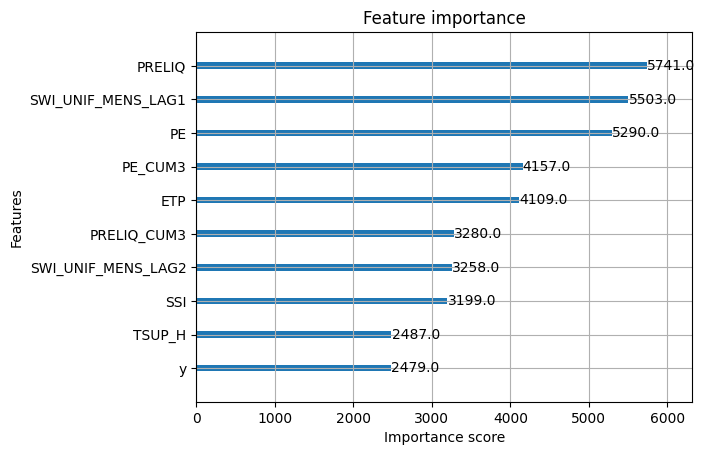

In [80]:
### Modèle de XGBoost temporel ###


# Préparation au XGBoost temporel

# Découpage de X_train et y_train en sous-ensembles d'apprentissage et de validation
X_train_train = X_train[masque_train_train].drop(columns = ["NUMERO", "DATE"], axis = 1)
y_train_train = y_train[masque_train_train]
X_val = X_train[masque_val].drop(columns = ["NUMERO", "DATE"], axis = 1)
y_val = y_train[masque_val]

# Paramètres du modèle XGBoost temporel
model_xgb_time = xgb.XGBRegressor(
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 5,
    tree_method = 'hist',
    n_jobs = -1,
    random_state = 42,
    early_stopping_rounds = 50,
    subsample = 0.7,
    min_child_weight = 50,
)


# Entraînement

# Texte de démarrage
print("Lancement de l'entraînement...")

# Entraînement du modèle
model_xgb_time.fit(
    X_train.drop(columns = ["NUMERO", "DATE"], axis = 1), y_train,
    eval_set = [(X_train_train, y_train_train), (X_val, y_val)],
    verbose = 50 
)


# Prédiction et évaluation sur l'échantillon de validation

# Calcul des prédictions
preds_val = model_xgb_time.predict(X_val)

# Calcul de la RMSE
rmse_val = metrics.root_mean_squared_error(y_val, preds_val)

# Affichage de la RMSE sur l'échantillon de validation
print(f"RMSE Finale : {rmse_val:.4f}")

# Graphique des importances des variables
xgb.plot_importance(model_xgb_time, max_num_features=10)
plt.show()

In [81]:
### Prévision récursive du modèle XGBoost temporel ###


# Initialisation

# Ajout d'une colonne vide de prédictions
X_test["SWI_UNIF_MENS_PRED_XGB"] = np.nan

# Vecteur de stockage des prédictions
predictions_all = []


# Boucle de prévision récursive

# Texte de démarrage
print("Début de la prévision récursive...")

# Boucle de prévision
for i, current_date in enumerate(dates_test):
    
    # Sélection des données du mois en cours pour l'ensemble des points
    mask_current = (X_test["DATE"] == current_date)
    X_current = X_test.loc[mask_current].drop(columns = ["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_XGB", "SWI_UNIF_MENS_PRED_RIDGE"])
    
    # Prédiction pour le mois
    y_pred_current = model_xgb_time.predict(X_current)
    
    # Sauvegarde des prédictions
    X_test.loc[mask_current, "SWI_UNIF_MENS_PRED_XGB"] = y_pred_current
    
    # Mise à jour des lags des lignes suivantes
    
    # Mise à jour du Lag 1 pour le mois suivant (t+1)
    if i + 1 < len(dates_test):
        next_date = dates_test[i + 1]
        # On injecte NOS prédictions comme étant le "passé" du mois suivant
        # On suppose que l'ordre des points est identique (d'où le sort_values au début)
        X_test.loc[X_test["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
    
    # Mise à jour du Lag 2 pour le mois d'après (t+2)
    if i + 2 < len(dates_test):
        next_next_date = dates_test[i + 2]
        X_test.loc[X_test["DATE"] == next_next_date, "SWI_UNIF_MENS_LAG2"] = y_pred_current

# Texte final
print("Terminé.")

C:\Users\elric\AppData\Local\Temp\ipykernel_8164\1901625396.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["SWI_UNIF_MENS_PRED_XGB"] = np.nan


Début de la prévision récursive...
Terminé.


In [82]:
### Affichage des résultats du XGBoost temporel ###


# Stockage des prédictions
preds_test_xgb_time = X_test["SWI_UNIF_MENS_PRED_XGB"]

# Prédiction sur la base de test
rmse_test_xgb_time = metrics.root_mean_squared_error(y_test, preds_test_xgb_time)

# Affichage des résultats
print("R² (train) :", model_xgb_time.score(X_train.drop(columns=["NUMERO", "DATE"], axis=1), y_train))
print("R² (test) :", model_xgb_time.score(X_test.drop(columns=["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_RIDGE", "SWI_UNIF_MENS_PRED_XGB"], axis=1), y_test))
print("RMSE (train) :", metrics.root_mean_squared_error(y_train, model_xgb_time.predict(X_train.drop(columns=["NUMERO", "DATE"], axis=1))))
print("RMSE (test) :", rmse_test_xgb_time)

R² (train) : 0.9820959568023682
R² (test) : 0.9766122698783875
RMSE (train) : 0.04353009909391403
RMSE (test) : 0.052184150609969046


Nous décidons de conserver le modèle XGBoost avec variables dépendant des observations précédentes car ses performances sont les meilleures, avec un R² de 0,977 et une RMSE de 0,052.

### Visualisation des résultats du modèle XGBoost avec variables dépendant des observations précédentes

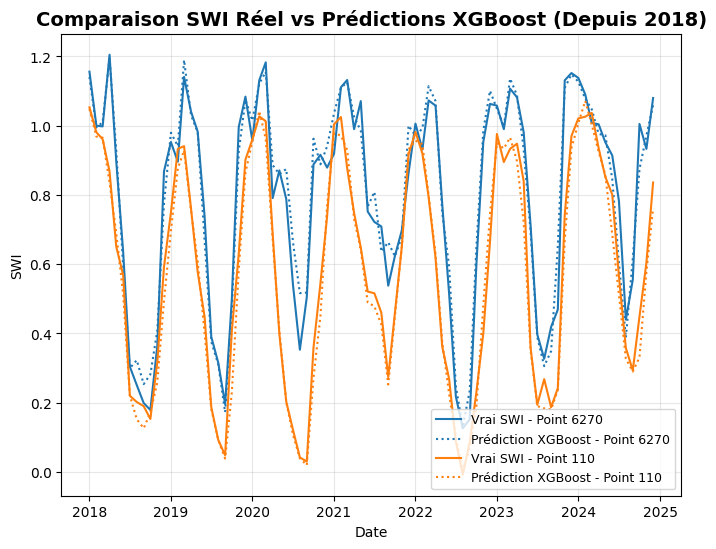

In [83]:
### Graphique de l'évolution des valeurs réelles et des prédictions pour quelques points de la grille ###


# Graine
np.random.seed(42)

# Sélection de quelques points de la grille
points_to_plot = np.random.choice(gdf["NUMERO"].unique(), size = 2, replace = False)

# Création du graphique
plt.figure(figsize=(8, 6))

# Création des courbes sur les dates sélectionnées
for i in range(len(points_to_plot)):
    
    # Sélection du point
    point = points_to_plot[i]

    # Courbe pour les données réelles
    
    # Filtre pour le point et les dates à partir de 2018
    mask_point_gdf = (gdf["NUMERO"] == point) & (gdf["DATE"] >= "2018-01-01")

    # Vecteur de dates
    dates_point = gdf.loc[mask_point_gdf, "DATE"]
    
    # Vecteur des valeurs
    y_true_point = gdf.loc[mask_point_gdf, "SWI_UNIF_MENS"]

    # Création de la courbe
    plt.plot(dates_point, y_true_point, color = f"C{i}", label=f"Vrai SWI - Point {point}", linestyle="-")
    
    
    # Courbe pour les prédictions XGBoost
    
    # Filtre pour le point sur la base de test
    mask_point_X_test = (X_test["NUMERO"] == point)

    # Vecteur des dates
    dates_point_test = X_test.loc[mask_point_X_test, "DATE"]
    
    # Vecteur des valeurs prédites
    y_pred_xgb_point = X_test.loc[mask_point_X_test, "SWI_UNIF_MENS_PRED_XGB"]
    
    # Création de la courbe
    plt.plot(dates_point_test, y_pred_xgb_point, color = f"C{i}", label=f"Prédiction XGBoost - Point {point}", linestyle=":")
    

# Mise en forme du graphique

# Titre
plt.title("Comparaison SWI Réel vs Prédictions XGBoost (Depuis 2018)", fontsize = 14, fontweight = "bold")

# Titres des axes
plt.xlabel("Date", fontsize = 10)
plt.ylabel("SWI", fontsize = 10)

# Légende
plt.legend(loc = "best", fontsize = 9)

# Ajout d'une grille pour faciliter la lecture
plt.grid(True, alpha = 0.3)

# Affichage
plt.show()

In [84]:
### Suppression des bases d'entraînement et de test pour libérer de la mémoire ###

del train, test, X_train, X_train_train, X_val, X_test, y_train, y_train_train, y_val, y_test
gc.collect()

8524

### Focus sur la région de la Nouvelle-Aquitaine

In [85]:
### Filtrage de la base pour conserver les points des départements de la Nouvelle-Aquitaine ###


# Liste des départements de la Nouvelle-Aquitaine
departements_nouv_aq = [16, 17, 19, 23, 24, 33, 40, 47, 64, 79, 86, 87]

# Filtrage de la base
gdf_nouv_aq = gdf[gdf["DPT"].isin(departements_nouv_aq)]

# Affichage de la base filtrée
display(gdf_nouv_aq)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1
7079,4493,437852,6668257,1960-01-01,0.853,6.400000,53.599998,4.374194,4.316129,4.782968,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16060,4493,437852,6668257,1960-02-01,0.920,0.000000,50.900002,5.634483,4.289655,4.863103,...,10.200000,0.622581,0.004097,0.141935,NaN,NaN,NaN,-0.622581,-0.004097,-0.141935
25041,4493,437852,6668257,1960-03-01,0.952,0.000000,71.300003,9.087097,3.254839,6.024161,...,0.000000,0.000000,0.000000,0.000000,6.400000,175.800003,97.800001,0.000000,0.000000,0.000000
34021,4493,437852,6668257,1960-04-01,0.767,0.000000,27.200001,10.503333,3.803333,6.214133,...,0.000000,0.000000,0.000000,0.000000,0.000000,149.400005,9.900000,0.000000,0.000000,0.000000
43003,4493,437852,6668257,1960-05-01,0.560,0.000000,80.599998,15.290322,2.948387,8.031516,...,0.000000,0.000000,0.000000,0.000000,0.000000,179.100002,-30.900000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997044,9556,425976,6196797,2024-08-01,0.339,0.000000,200.600006,14.112904,1.619355,7.643839,...,0.000000,0.000000,0.000000,0.000000,0.900000,377.500004,95.099995,0.000000,0.000000,0.000000
6997051,9556,425976,6196797,2024-09-01,0.977,5.000000,307.799988,7.010000,1.746667,5.810133,...,0.000000,0.000000,0.000000,0.000000,5.000000,559.199993,288.499996,0.033333,0.000200,0.006667
6997049,9556,425976,6196797,2024-10-01,1.176,106.699997,330.000000,6.603226,1.903226,5.992484,...,5.100000,0.033333,0.000200,0.006667,111.699997,838.399994,734.499985,9.002151,0.040252,0.183656
6997048,9556,425976,6196797,2024-11-01,1.022,39.099998,58.200001,3.753333,2.396667,4.470700,...,103.400002,9.035484,0.040452,0.190323,150.799995,695.999989,698.999985,-1.415484,-0.008585,0.076344


In [86]:
### Découpage de la base en bases d'entraînement et de test ###

# Bases d'entraînement et de test
train_nouv_aq = gdf_nouv_aq[(gdf_nouv_aq["DATE"] < "2018-01-01") & (gdf_nouv_aq["SWI_UNIF_MENS_LAG2"].notna())]
test_nouv_aq = gdf_nouv_aq[gdf_nouv_aq["DATE"] >= "2018-01-01"]

# X et y d'entraînement
X_train_nouv_aq = train_nouv_aq[X_cols]
y_train_nouv_aq = train_nouv_aq["SWI_UNIF_MENS"]

# X et y de test
X_test_nouv_aq = test_nouv_aq[X_cols]
y_test_nouv_aq = test_nouv_aq["SWI_UNIF_MENS"]

# Création de masques pour le découpage de la base d'entraînement
masque_train_train_nouv_aq = train_nouv_aq["DATE"] < "2017-01-01"
masque_val_nouv_aq = train_nouv_aq["DATE"] >= "2017-01-01"

In [87]:
gdf_nouv_aq

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1
7079,4493,437852,6668257,1960-01-01,0.853,6.400000,53.599998,4.374194,4.316129,4.782968,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16060,4493,437852,6668257,1960-02-01,0.920,0.000000,50.900002,5.634483,4.289655,4.863103,...,10.200000,0.622581,0.004097,0.141935,NaN,NaN,NaN,-0.622581,-0.004097,-0.141935
25041,4493,437852,6668257,1960-03-01,0.952,0.000000,71.300003,9.087097,3.254839,6.024161,...,0.000000,0.000000,0.000000,0.000000,6.400000,175.800003,97.800001,0.000000,0.000000,0.000000
34021,4493,437852,6668257,1960-04-01,0.767,0.000000,27.200001,10.503333,3.803333,6.214133,...,0.000000,0.000000,0.000000,0.000000,0.000000,149.400005,9.900000,0.000000,0.000000,0.000000
43003,4493,437852,6668257,1960-05-01,0.560,0.000000,80.599998,15.290322,2.948387,8.031516,...,0.000000,0.000000,0.000000,0.000000,0.000000,179.100002,-30.900000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997044,9556,425976,6196797,2024-08-01,0.339,0.000000,200.600006,14.112904,1.619355,7.643839,...,0.000000,0.000000,0.000000,0.000000,0.900000,377.500004,95.099995,0.000000,0.000000,0.000000
6997051,9556,425976,6196797,2024-09-01,0.977,5.000000,307.799988,7.010000,1.746667,5.810133,...,0.000000,0.000000,0.000000,0.000000,5.000000,559.199993,288.499996,0.033333,0.000200,0.006667
6997049,9556,425976,6196797,2024-10-01,1.176,106.699997,330.000000,6.603226,1.903226,5.992484,...,5.100000,0.033333,0.000200,0.006667,111.699997,838.399994,734.499985,9.002151,0.040252,0.183656
6997048,9556,425976,6196797,2024-11-01,1.022,39.099998,58.200001,3.753333,2.396667,4.470700,...,103.400002,9.035484,0.040452,0.190323,150.799995,695.999989,698.999985,-1.415484,-0.008585,0.076344


Lancement de l'entraînement...
[0]	validation_0-rmse:0.31906	validation_1-rmse:0.29589
[50]	validation_0-rmse:0.06695	validation_1-rmse:0.06604
[100]	validation_0-rmse:0.05565	validation_1-rmse:0.05624
[150]	validation_0-rmse:0.05320	validation_1-rmse:0.05361
[200]	validation_0-rmse:0.05148	validation_1-rmse:0.05131
[250]	validation_0-rmse:0.04995	validation_1-rmse:0.04972
[300]	validation_0-rmse:0.04857	validation_1-rmse:0.04862
[350]	validation_0-rmse:0.04744	validation_1-rmse:0.04771
[400]	validation_0-rmse:0.04644	validation_1-rmse:0.04679
[450]	validation_0-rmse:0.04544	validation_1-rmse:0.04588
[500]	validation_0-rmse:0.04463	validation_1-rmse:0.04517
[550]	validation_0-rmse:0.04388	validation_1-rmse:0.04476
[600]	validation_0-rmse:0.04319	validation_1-rmse:0.04417
[650]	validation_0-rmse:0.04252	validation_1-rmse:0.04367
[700]	validation_0-rmse:0.04186	validation_1-rmse:0.04316
[750]	validation_0-rmse:0.04127	validation_1-rmse:0.04283
[800]	validation_0-rmse:0.04079	validation_1

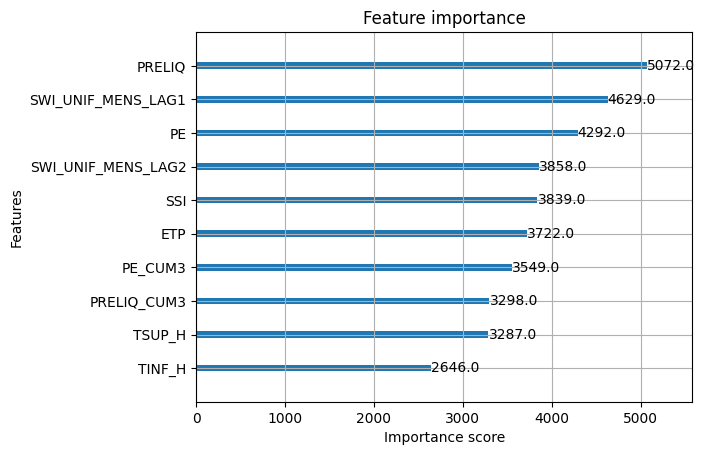

In [88]:
### Modèle de XGBoost sans CV pour la Nouvelle-Aquitaine ###


# Préparation au XGBoost pour la Nouvelle-Aquitaine

# Découpage de X_train et y_train en sous-ensembles d'apprentissage et de validation
X_train_train = X_train_nouv_aq[masque_train_train_nouv_aq].drop(columns = ["NUMERO", "DATE"], axis = 1)
y_train_train = y_train_nouv_aq[masque_train_train_nouv_aq]
X_val = X_train_nouv_aq[masque_val_nouv_aq].drop(columns = ["NUMERO", "DATE"], axis = 1)
y_val = y_train_nouv_aq[masque_val_nouv_aq]

# Paramètres du modèle XGBoost pour la Nouvelle-Aquitaine
model_xgb_time_nouv_aq = xgb.XGBRegressor(
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 5,
    tree_method = 'hist',
    n_jobs = -1,
    random_state = 42,
    early_stopping_rounds = 50,
    subsample = 0.7,
    min_child_weight = 50,
)


# Entraînement

# Texte de démarrage
print("Lancement de l'entraînement...")

# Entraînement du modèle
model_xgb_time_nouv_aq.fit(
    X_train_nouv_aq.drop(columns = ["NUMERO", "DATE"], axis = 1), y_train_nouv_aq,
    eval_set = [(X_train_train, y_train_train), (X_val, y_val)],
    verbose = 50 
)


# Prédiction et évaluation sur l'échantillon de validation

# Calcul des prédictions
preds_val_nouv_aq = model_xgb_time_nouv_aq.predict(X_val)

# Calcul de la RMSE
rmse_val_nouv_aq = metrics.root_mean_squared_error(y_val, preds_val_nouv_aq)

# Affichage de la RMSE sur l'échantillon de validation
print(f"RMSE Finale : {rmse_val_nouv_aq:.4f}")

# Graphique des importances des variables
xgb.plot_importance(model_xgb_time_nouv_aq, max_num_features=10)
plt.show()

In [89]:
### Prévision récursive du modèle pour la Nouvelle-Aquitaine ###


# Initialisation

# Ajout d'une colonne vide de prédictions
X_test_nouv_aq["SWI_UNIF_MENS_PRED_XGB"] = np.nan

# Vecteur de stockage des prédictions
predictions_all = []


# Boucle de prévision récursive

# Texte de démarrage
print("Début de la prévision récursive...")

# Boucle de prévision
for i, current_date in enumerate(dates_test):
    
    # Sélection des données du mois en cours pour l'ensemble des points
    mask_current = (X_test_nouv_aq["DATE"] == current_date)
    X_current = X_test_nouv_aq.loc[mask_current].drop(columns = ["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_XGB"])
    
    # Prédiction pour le mois
    y_pred_current = model_xgb_time_nouv_aq.predict(X_current)
    
    # Sauvegarde des prédictions
    X_test_nouv_aq.loc[mask_current, "SWI_UNIF_MENS_PRED_XGB"] = y_pred_current
    
    # Mise à jour des lags des lignes suivantes
    
    # Mise à jour du Lag 1 pour le mois suivant (t+1)
    if i + 1 < len(dates_test):
        next_date = dates_test[i + 1]
        # On injecte NOS prédictions comme étant le "passé" du mois suivant
        # On suppose que l'ordre des points est identique (d'où le sort_values au début)
        X_test_nouv_aq.loc[X_test_nouv_aq["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
    
    # Mise à jour du Lag 2 pour le mois d'après (t+2)
    if i + 2 < len(dates_test):
        next_next_date = dates_test[i + 2]
        X_test_nouv_aq.loc[X_test_nouv_aq["DATE"] == next_next_date, "SWI_UNIF_MENS_LAG2"] = y_pred_current

# Texte final
print("Terminé.")

Début de la prévision récursive...


C:\Users\elric\AppData\Local\Temp\ipykernel_8164\2296971941.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_nouv_aq["SWI_UNIF_MENS_PRED_XGB"] = np.nan


Terminé.


In [90]:
### Affichage des résultats du XGBoost temporel pour la Nouvelle-Aquitaine ###


# Stockage des prédictions
preds_test_xgb_time_nouv_aq = X_test_nouv_aq["SWI_UNIF_MENS_PRED_XGB"]

# Prédiction sur la base de test
rmse_test_xgb_time_nouv_aq = metrics.root_mean_squared_error(y_test_nouv_aq, preds_test_xgb_time_nouv_aq)

# Affichage des résultats
print("R² (train) :", model_xgb_time_nouv_aq.score(X_train_nouv_aq.drop(columns = ["NUMERO", "DATE"], axis = 1), y_train_nouv_aq))
print("R² (test) :", model_xgb_time_nouv_aq.score(X_test_nouv_aq.drop(columns = ["NUMERO", "DATE", "SWI_UNIF_MENS_PRED_XGB"], axis = 1), y_test_nouv_aq))
print("RMSE (train) :", metrics.root_mean_squared_error(y_train_nouv_aq, model_xgb_time_nouv_aq.predict(X_train_nouv_aq.drop(columns = ["NUMERO", "DATE"], axis = 1))))
print("RMSE (test) :", rmse_test_xgb_time_nouv_aq)

R² (train) : 0.9902880787849426
R² (test) : 0.9745395183563232
RMSE (train) : 0.03293810412287712
RMSE (test) : 0.05527232025119469


In [91]:
### Suppression des bases d'entraînement pour libérer de la mémoire ###


del train_nouv_aq, test_nouv_aq, X_train_nouv_aq, X_test_nouv_aq, X_train_train, X_val, y_train_nouv_aq, y_test_nouv_aq, y_train_train, y_val
gc.collect()

4314

# Modélisation des événements de sécheresse avec la règle métier

### Ajout d'une variable indicatrice de sécheresse

La méthode employée par Météo France consiste à dans un premier temps calculer la moyenne glissante de l'indice SWI sur une période de 90 jours. Si cette moyenne glissante descend en-dessous d'un seuil correspondant à une période de retour de 25 ans, alors la période est considérée comme une période de sécheresse.

In [92]:
### Calcul de la moyenne glissante sur 3 mois pour la base ###


# Calcul de la moyenne glissante sur 3 mois pour chaque point de la grille
gdf["SWI_UNIF_MENS_MA3"] = gdf.groupby("NUMERO")["SWI_UNIF_MENS"].rolling(window = 3).mean().reset_index(level = 0, drop = True)

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3
105930,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105924,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,0.287097,0.00171,0.096774,NaN,NaN,NaN,-0.287097,-0.00171,-0.096774,NaN
105929,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,0.000000,0.00000,0.000000,5.4,131.000000,35.900000,0.000000,0.00000,0.000000,0.865000
105928,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,0.000000,0.00000,0.000000,0.5,86.300000,-13.200001,0.000000,0.00000,0.000000,0.829667
105925,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,0.000000,0.00000,0.000000,0.0,143.499997,19.699998,0.000000,0.00000,0.000000,0.762000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,0.000000,0.00000,0.000000,0.0,48.900000,-32.999999,0.000000,0.00000,0.000000,0.006333
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,0.000000,0.00000,0.000000,0.0,100.799998,-6.700000,0.000000,0.00000,0.000000,-0.010333
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,0.000000,0.00000,0.000000,0.0,188.699995,55.600002,0.000000,0.00000,0.000000,0.052667
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.000000,0.00000,0.000000,0.0,181.199995,38.800002,0.000000,0.00000,0.000000,0.101000


In [93]:
### Détermination de la valeur correspondant à une période de retour de 25 ans ###


# Isolation du minimum annuel de SWI_UNIF_MENS_MA3 pour chaque point de la grille

# Copie de gdf
gdf_min_annual = gdf.copy()

# Extraction de l'année
gdf_min_annual["year"] = gdf_min_annual["DATE"].dt.year

# Calcul du minimum annuel
gdf_min_annual = gdf_min_annual.groupby(["NUMERO", "year"])["SWI_UNIF_MENS_MA3"].min().reset_index()

# Calcul du quantile à 4 % (période de retour de 25 ans) pour chaque point
gdf_min_annual = gdf_min_annual.groupby("NUMERO")["SWI_UNIF_MENS_MA3"].quantile(0.04).reset_index()

# Affichage
display(gdf_min_annual)

,NUMERO,SWI_UNIF_MENS_MA3
0,2,0.071933
1,3,0.071933
2,4,0.072413
3,5,0.071933
4,6,0.071933
...,...,...
8976,9888,-0.036133
8977,9889,-0.037320
8978,9890,-0.035653
8979,9891,-0.036947


In [94]:
### Variable indicatrice de passage sous le seuil de SWI correspondant à une période de retour de 25 ans ###


# Colonne indicatrice
gdf["SECHERESSE"] = 0

# Liste des points de la grille
points_grille = gdf_min_annual["NUMERO"].unique()

# Boucle pour chaque point de la grille
for point in points_grille:
    
    # Valeur du quantile 4 % pour le point
    seuil_point = gdf_min_annual.loc[gdf_min_annual["NUMERO"] == point, "SWI_UNIF_MENS_MA3"].values[0]
    
    # Mise à jour de la colonne indicatrice
    gdf.loc[(gdf["NUMERO"] == point) & (gdf["SWI_UNIF_MENS_MA3"] < seuil_point), "SECHERESSE"] = 1
    
# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3,SECHERESSE
105930,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
105924,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,0.00171,0.096774,NaN,NaN,NaN,-0.287097,-0.00171,-0.096774,NaN,0
105929,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,0.00000,0.000000,5.4,131.000000,35.900000,0.000000,0.00000,0.000000,0.865000,0
105928,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,0.00000,0.000000,0.5,86.300000,-13.200001,0.000000,0.00000,0.000000,0.829667,0
105925,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,0.00000,0.000000,0.0,143.499997,19.699998,0.000000,0.00000,0.000000,0.762000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,0.00000,0.000000,0.0,48.900000,-32.999999,0.000000,0.00000,0.000000,0.006333,0
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,0.00000,0.000000,0.0,100.799998,-6.700000,0.000000,0.00000,0.000000,-0.010333,0
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,0.00000,0.000000,0.0,188.699995,55.600002,0.000000,0.00000,0.000000,0.052667,0
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.00000,0.000000,0.0,181.199995,38.800002,0.000000,0.00000,0.000000,0.101000,0


In [95]:
### Affichage de lignes où SECHERESSE == 1 ###


display(gdf[gdf["SECHERESSE"] == 1])

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3,SECHERESSE
3339086,2,641374,7106309,1990-09-01,0.011,0.0,44.400002,15.150000,4.860000,8.046567,...,0.0,0.0,0.0,88.900001,-2.600001,0.0,0.0,0.0,0.052000,1
3339087,2,641374,7106309,1990-10-01,0.055,0.0,82.099998,13.364516,4.893548,7.746548,...,0.0,0.0,0.0,156.799999,62.199998,0.0,0.0,0.0,0.027333,1
5602304,2,641374,7106309,2011-11-01,0.063,0.0,22.500000,9.030000,3.993333,6.487900,...,0.0,0.0,0.0,93.899998,1.000000,0.0,0.0,0.0,0.063667,1
6787790,2,641374,7106309,2022-09-01,0.131,0.0,159.699997,16.463333,3.666667,8.779266,...,0.0,0.0,0.0,177.499997,84.500003,0.0,0.0,0.0,0.066333,1
3333778,3,649370,7106242,1990-09-01,0.011,0.0,44.400002,15.150000,4.856667,8.045366,...,0.0,0.0,0.0,88.900001,-0.599999,0.0,0.0,0.0,0.052333,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214261,9892,1215772,6046242,1961-09-01,-0.049,0.0,1.200000,21.943333,1.346667,11.155666,...,0.0,0.0,0.0,1.500000,-19.200000,0.0,0.0,0.0,-0.039000,1
322034,9892,1215772,6046242,1962-09-01,-0.046,0.0,17.600000,21.583334,1.510000,10.658500,...,0.0,0.0,0.0,18.100000,-12.300000,0.0,0.0,0.0,-0.039667,1
1184217,9892,1215772,6046242,1970-09-01,-0.052,0.0,1.200000,21.706667,1.406667,11.431133,...,0.0,0.0,0.0,5.500000,-20.000000,0.0,0.0,0.0,-0.042333,1
1184210,9892,1215772,6046242,1970-10-01,-0.057,0.0,1.900000,16.851612,1.970968,8.245226,...,0.0,0.0,0.0,6.500000,-9.700000,0.0,0.0,0.0,-0.051000,1


### Prédiction de la sécheresse à partir des prédictions du modèle XGBoost de régression

Le modèle de XGBoost de régression prédit l'indice SWI avec de bons résultats. Nous utilisons donc ces prédictions pour calculer une moyenne glissante sur 90 jours, puis nous appliquons le seuil pour détecter les périodes de sécheresse.

In [96]:
### Isolement de la base de test pour la modélisation de la sécheresse et ajout des prédictions de SWI ###


# Base de test
test = gdf[gdf["DATE"] >= "2018-01-01"].copy()

# Ajout des prédictions XGBoost temporel
test["SWI_UNIF_MENS_PRED_XGB"] = preds_test_xgb_time

# Ajout de la moyenne glissante sur 3 mois des prédictions XGBoost temporel
test["SWI_UNIF_MENS_PRED_XGB_MA3"] = test.groupby("NUMERO")["SWI_UNIF_MENS_PRED_XGB"].rolling(window = 3).mean().reset_index(level = 0, drop = True)

# Ajout de la colonne indicatrice de sécheresse basée sur les prédictions
test["SECHERESSE_PRED"] = 0

# Remplissage de la colonne
for point in points_grille:
    
    # Valeur du quantile 4 % pour le point
    seuil_point = gdf_min_annual.loc[gdf_min_annual["NUMERO"] == point, "SWI_UNIF_MENS_MA3"].values[0]
    
    # Mise à jour de la colonne indicatrice
    test.loc[(test["NUMERO"] == point) & (test["SWI_UNIF_MENS_PRED_XGB_MA3"] < seuil_point), "SECHERESSE_PRED"] = 1

# Affichage de la base
display(test)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3,SECHERESSE,SWI_UNIF_MENS_PRED_XGB,SWI_UNIF_MENS_PRED_XGB_MA3,SECHERESSE_PRED
6356706,2,641374,7106309,2018-01-01,0.970,0.0,85.599998,6.854839,5.638710,5.212387,...,272.500000,184.699997,0.0,0.0,0.0,0.690000,0,0.924495,NaN,0
6356704,2,641374,7106309,2018-02-01,0.951,0.0,34.700001,2.825000,5.264286,3.501429,...,227.799999,135.999996,0.0,0.0,0.0,0.884333,0,0.938010,NaN,0
6356708,2,641374,7106309,2018-03-01,0.924,0.0,64.099998,5.629032,4.500000,4.694387,...,184.399998,91.200001,0.0,0.0,0.0,0.948333,0,0.905541,0.922682,0
6356700,2,641374,7106309,2018-04-01,0.865,0.0,63.700001,11.493333,3.960000,6.660533,...,162.500000,49.200002,0.0,0.0,0.0,0.913333,0,0.812199,0.885250,0
6356705,2,641374,7106309,2018-05-01,0.672,0.0,43.799999,13.477419,3.422581,7.884226,...,171.599998,32.100001,0.0,0.0,0.0,0.820333,0,0.695370,0.804370,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,48.900000,-32.999999,0.0,0.0,0.0,0.006333,0,-0.024876,0.010500,0
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,100.799998,-6.700000,0.0,0.0,0.0,-0.010333,0,0.043045,-0.003461,0
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,188.699995,55.600002,0.0,0.0,0.0,0.052667,0,0.162176,0.060115,0
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,181.199995,38.800002,0.0,0.0,0.0,0.101000,0,0.171983,0.125735,0


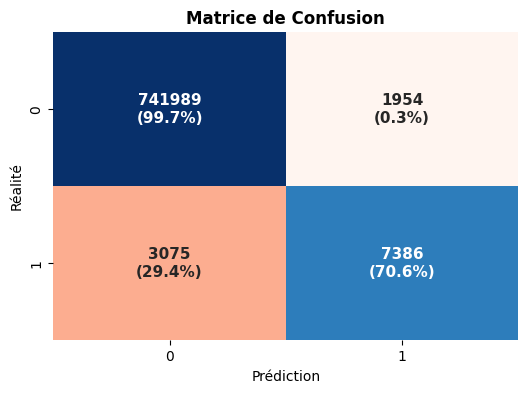

In [97]:
### Création d'une matrice de confusion pour évaluer les prédictions de sécheresse ###


# Création de la matrice de confusion
matrice_confusion = pd.crosstab(
    test["SECHERESSE"],
    test["SECHERESSE_PRED"],
    rownames = ["Vrai"],
    colnames = ["Prédit"]
)

# Calcul des pourcentages dans la matrice de confusion
cm_percent = matrice_confusion.div(matrice_confusion.sum(axis=1), axis=0) * 100

# Création des labels (Nombre + %)
labels = (np.asarray(["{0}\n({1:.1f}%)".format(count, pct)
                      for count, pct in zip(matrice_confusion.values.flatten(),
                                            cm_percent.values.flatten())])
         ).reshape(matrice_confusion.shape)

# Coloration du graphique avec seaborn

# Masque pour colorer en bleu pour les bonnes réponses (diagonale)
mask_for_blue = np.array([[False, True], 
                          [True, False]])

# Masque pour colorer en rouge pour les erreurs (hors diagonale)
mask_for_red = np.array([[True, False], 
                         [False, True]])

# Création de la figure
plt.figure(figsize = (6, 4))

# Bonnes réponses en bleu (Diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_blue,  # On cache les erreurs
            annot = labels, 
            fmt = "", 
            cmap = "Blues",        # Palette Bleue
            vmin = 0, vmax = 100,    # Échelle 0-100%
            cbar = False,          # Suppression de la barre de couleur
            annot_kws = {"size": 11, "weight": "bold"})

# Mauvaises réponses en rouge (Hors diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_red,   # On cache les bonnes réponses
            annot = labels, 
            fmt = "", 
            cmap = "Reds",         # Palette Rouge
            vmin = 0, vmax = 100, 
            cbar = False, 
            annot_kws = {"size": 11, "weight": "bold"})

plt.title("Matrice de Confusion", fontsize = 12, weight = "bold")
plt.ylabel("Réalité", fontsize = 10)
plt.xlabel("Prédiction", fontsize = 10)

plt.show()

In [98]:
### Calcul de la précision, du rappel et du F2-score ###


# Nous choisissons de calculer le F2-score pour accorder plus d'importance au rappel (recall)
# La gravité des faux négatifs est plus élevée dans ce contexte que celle des faux positifs

# Calcul de la précision
precision = metrics.precision_score(test["SECHERESSE"], test["SECHERESSE_PRED"])

# Calcul du rappel
recall = metrics.recall_score(test["SECHERESSE"], test["SECHERESSE_PRED"])

# Calcul du F2-score
f2_score = metrics.fbeta_score(test["SECHERESSE"], test["SECHERESSE_PRED"], beta=2)

# Affichage des résultats
print(f"Précision : {precision:.4f}")
print(f"Rappel : {recall:.4f}")
print(f"F2-score : {f2_score:.4f}")

Précision : 0.7908
Rappel : 0.7061
F2-score : 0.7215


Le rappel et le F2-score sont élevées, mais peuvent être améliorées. La valeur de rappel indique que le modèle de XGBoost capte difficilement les valeurs extrêmes. Nous allons donc tenter d'améliorer la performance de notre modèle de classification en appliquant une coefficient multiplicateur aux seuils de sécheresse afin de capturer davantage les cas extrêmes.

In [99]:
### Détermination du meilleur coefficient multiplicateur pour maximiser la précision, le rappel et le F2-score ###


# Liste des coefficients à tester
coefficients = np.arange(1, 1.55, 0.05)

# Initialisation des listes pour stocker les résultats
precisions = []
recalls = []
f2_scores = []

# Boucle sur chaque coefficient
for coeff in coefficients:
    
    # Création d'une colonne indicatrice de sécheresse basée sur les prédictions ajustées
    test["SECHERESSE_PRED_ADJUSTED"] = 0

    # Remplissage de la colonne avec le coefficient ajusté
    for point in points_grille:
        
        # Valeur du quantile 4 % pour le point
        seuil_point = gdf_min_annual.loc[gdf_min_annual["NUMERO"] == point, "SWI_UNIF_MENS_MA3"].values[0]
        
        # Mise à jour de la colonne indicatrice
        test.loc[(test["NUMERO"] == point) & (test["SWI_UNIF_MENS_PRED_XGB_MA3"] < seuil_point * coeff), "SECHERESSE_PRED_ADJUSTED"] = 1
    
    # Calcul de la précision
    precision = metrics.precision_score(test["SECHERESSE"], test["SECHERESSE_PRED_ADJUSTED"])
    precisions.append(precision)
    
    # Calcul du rappel
    recall = metrics.recall_score(test["SECHERESSE"], test["SECHERESSE_PRED_ADJUSTED"])
    recalls.append(recall)
    
    # Calcul du F2-score
    f2 = metrics.fbeta_score(test["SECHERESSE"], test["SECHERESSE_PRED_ADJUSTED"], beta=2)
    f2_scores.append(f2)

# Suppression de la colonne temporaire
del test["SECHERESSE_PRED_ADJUSTED"]
    
# Création d'un DataFrame pour les résultats
results_df = pd.DataFrame({
    "Coefficient": coefficients,
    "Précision": precisions,
    "Rappel": recalls,
    "F2-score": f2_scores
})

# Affichage des résultats
display(results_df)

,Coefficient,Précision,Rappel,F2-score
0,1.00,0.790792,0.706051,0.721515
1,1.05,0.750071,0.757385,0.755910
2,1.10,0.708839,0.798012,0.778426
3,1.15,0.665466,0.829844,0.790778
4,1.20,0.621465,0.852978,0.793833
5,1.25,0.580787,0.870376,0.791450
6,1.30,0.544305,0.880795,0.783877
7,1.35,0.506338,0.889685,0.772686
8,1.40,0.471088,0.895612,0.758845
9,1.45,0.440843,0.903642,0.746836


Nous choisissons le coefficient multiplicateur de 1,20 car il permet d'atteindre le F2-score le plus élevé, avec une valeur de 0,794. En particulier, nous pouvons noter une forte amélioration du rappel (0,852 contre 0,706 précédemment).

Pour réaliser des prédictions plus prudentes de la sécheresse, ce coefficient multiplicateur est un choix optimal.

In [100]:
### Ajout d'une colonne de prédiction prudente ###


# Choix du meilleur coefficient (celui qui maximise le F2-score)
best_coeff = 1.20

# Création d'une colonne indicatrice de sécheresse basée sur les prédictions ajustées
test["SECHERESSE_PRED_PRUDENT"] = 0

# Remplissage de la colonne avec le coefficient ajusté
for point in points_grille:
    
    # Valeur du quantile 4 % pour le point
    seuil_point = gdf_min_annual.loc[gdf_min_annual["NUMERO"] == point, "SWI_UNIF_MENS_MA3"].values[0]
    
    # Mise à jour de la colonne indicatrice
    test.loc[(test["NUMERO"] == point) & (test["SWI_UNIF_MENS_PRED_XGB_MA3"] < seuil_point * best_coeff), "SECHERESSE_PRED_PRUDENT"] = 1

# Affichage de la base
display(test)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3,SECHERESSE,SWI_UNIF_MENS_PRED_XGB,SWI_UNIF_MENS_PRED_XGB_MA3,SECHERESSE_PRED,SECHERESSE_PRED_PRUDENT
6356706,2,641374,7106309,2018-01-01,0.970,0.0,85.599998,6.854839,5.638710,5.212387,...,184.699997,0.0,0.0,0.0,0.690000,0,0.924495,NaN,0,0
6356704,2,641374,7106309,2018-02-01,0.951,0.0,34.700001,2.825000,5.264286,3.501429,...,135.999996,0.0,0.0,0.0,0.884333,0,0.938010,NaN,0,0
6356708,2,641374,7106309,2018-03-01,0.924,0.0,64.099998,5.629032,4.500000,4.694387,...,91.200001,0.0,0.0,0.0,0.948333,0,0.905541,0.922682,0,0
6356700,2,641374,7106309,2018-04-01,0.865,0.0,63.700001,11.493333,3.960000,6.660533,...,49.200002,0.0,0.0,0.0,0.913333,0,0.812199,0.885250,0,0
6356705,2,641374,7106309,2018-05-01,0.672,0.0,43.799999,13.477419,3.422581,7.884226,...,32.100001,0.0,0.0,0.0,0.820333,0,0.695370,0.804370,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003901,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,-32.999999,0.0,0.0,0.0,0.006333,0,-0.024876,0.010500,0,0
7003907,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,-6.700000,0.0,0.0,0.0,-0.010333,0,0.043045,-0.003461,0,0
7003902,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,55.600002,0.0,0.0,0.0,0.052667,0,0.162176,0.060115,0,0
7003899,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,38.800002,0.0,0.0,0.0,0.101000,0,0.171983,0.125735,0,0


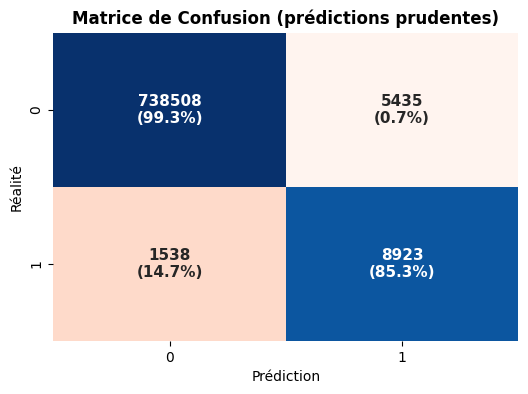

In [101]:
### Création d'une matrice de confusion pour évaluer les prédictions de sécheresse ###


# Création de la matrice de confusion
matrice_confusion2 = pd.crosstab(
    test["SECHERESSE"],
    test["SECHERESSE_PRED_PRUDENT"],
    rownames = ["Vrai"],
    colnames = ["Prédit"]
)

# Calcul des pourcentages dans la matrice de confusion
cm_percent = matrice_confusion2.div(matrice_confusion2.sum(axis=1), axis=0) * 100

# Création des labels (Nombre + %)
labels = (np.asarray(["{0}\n({1:.1f}%)".format(count, pct)
                      for count, pct in zip(matrice_confusion2.values.flatten(),
                                            cm_percent.values.flatten())])
         ).reshape(matrice_confusion2.shape)

# Coloration du graphique avec seaborn

# Masque pour colorer en bleu pour les bonnes réponses (diagonale)
mask_for_blue = np.array([[False, True], 
                          [True, False]])

# Masque pour colorer en rouge pour les erreurs (hors diagonale)
mask_for_red = np.array([[True, False], 
                         [False, True]])

# Création de la figure
plt.figure(figsize = (6, 4))

# Bonnes réponses en bleu (Diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_blue,  # On cache les erreurs
            annot = labels, 
            fmt = "", 
            cmap = "Blues",        # Palette Bleue
            vmin = 0, vmax = 100,    # Échelle 0-100%
            cbar = False,          # Suppression de la barre de couleur
            annot_kws = {"size": 11, "weight": "bold"})

# Mauvaises réponses en rouge (Hors diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_red,   # On cache les bonnes réponses
            annot = labels, 
            fmt = "", 
            cmap = "Reds",         # Palette Rouge
            vmin = 0, vmax = 100, 
            cbar = False, 
            annot_kws = {"size": 11, "weight": "bold"})

plt.title("Matrice de Confusion (prédictions prudentes)", fontsize = 12, weight = "bold")
plt.ylabel("Réalité", fontsize = 10)
plt.xlabel("Prédiction", fontsize = 10)

plt.show()

### Modélisation des événements de sécheresse pour la Nouvelle-Aquitaine

Nous commençons par utiliser le modèle de XGBoost spécifique à la Nouvelle-Aquitaine avant de comparer les résultats avec ceux obtenus en utilisant le modèle global.

In [102]:
### Filtrage de la base de test pour la Nouvelle-Aquitaine ###


# Isolement des points de la Nouvelle-Aquitaine
test_nouv_aq = test[test["DPT"].isin(departements_nouv_aq)]

# Ajout des prédictions XGBoost temporel
test_nouv_aq["SWI_UNIF_MENS_PRED_XGB_NA"] = preds_test_xgb_time_nouv_aq

# Ajout de la moyenne glissante sur 3 mois des prédictions XGBoost temporel
test_nouv_aq["SWI_UNIF_MENS_PRED_XGB_NA_MA3"] = test_nouv_aq.groupby("NUMERO")["SWI_UNIF_MENS_PRED_XGB_NA"].rolling(window = 3).mean().reset_index(level = 0, drop = True)

# Création d'une colonne indicatrice de sécheresse basée sur les prédictions ajustées avec le modèle spécifique
test_nouv_aq["SECHERESSE_PRED_PRUDENT_NA"] = 0

# Liste des points de la grille en Nouvelle-Aquitaine
points_grille_nouv_aq = test_nouv_aq["NUMERO"].unique()

# Remplissage de la colonne avec le coefficient ajusté
for point in points_grille_nouv_aq:

    # Valeur du quantile 4 % pour le point
    seuil_point = gdf_min_annual.loc[gdf_min_annual["NUMERO"] == point, "SWI_UNIF_MENS_MA3"].values[0]
    
    # Mise à jour de la colonne indicatrice
    test_nouv_aq.loc[(test_nouv_aq["NUMERO"] == point) & (test_nouv_aq["SWI_UNIF_MENS_PRED_XGB_NA_MA3"] < seuil_point * best_coeff), "SECHERESSE_PRED_PRUDENT_NA"] = 1

# Affichage de la base
display(test_nouv_aq)

c:\Users\elric\Desktop\Scolaire\Cours\MS\S1\Climate Risk\Climate_Risk_Project_SWI_MS_A\Climate_Risk_Project_SWI_MS_A\.venv\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\elric\Desktop\Scolaire\Cours\MS\S1\Climate Risk\Climate_Risk_Project_SWI_MS_A\Climate_Risk_Project_SWI_MS_A\.venv\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\e

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,SNOW_FRAC_DIFF1,SWI_UNIF_MENS_MA3,SECHERESSE,SWI_UNIF_MENS_PRED_XGB,SWI_UNIF_MENS_PRED_XGB_MA3,SECHERESSE_PRED,SECHERESSE_PRED_PRUDENT,SWI_UNIF_MENS_PRED_XGB_NA,SWI_UNIF_MENS_PRED_XGB_NA_MA3,SECHERESSE_PRED_PRUDENT_NA
6257855,4493,437852,6668257,2018-01-01,0.709,0.000000,137.100006,8.322580,4.248387,6.345226,...,-0.003226,0.319000,0,0.705798,NaN,0,0,0.700714,NaN,0
6266835,4493,437852,6668257,2018-02-01,0.940,13.600000,50.700001,2.878572,3.446429,4.081572,...,0.021429,0.626000,0,0.894345,NaN,0,0,0.910728,NaN,0
6275817,4493,437852,6668257,2018-03-01,0.968,0.700000,102.300003,7.445161,4.103226,5.368871,...,-0.011751,0.872333,0,0.973077,0.857740,0,0,0.974019,0.861820,0
6284798,4493,437852,6668257,2018-04-01,0.896,0.000000,54.799999,12.486667,2.540000,6.912300,...,-0.009677,0.934667,0,0.850708,0.906043,0,0,0.859923,0.914890,0
6293778,4493,437852,6668257,2018-05-01,0.506,0.000000,38.200001,15.325807,2.383871,8.201129,...,0.000000,0.790000,0,0.585967,0.803251,0,0,0.609944,0.814629,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997044,9556,425976,6196797,2024-08-01,0.339,0.000000,200.600006,14.112904,1.619355,7.643839,...,0.000000,0.590000,0,0.458757,0.627781,0,0,0.398959,0.614334,0
6997051,9556,425976,6196797,2024-09-01,0.977,5.000000,307.799988,7.010000,1.746667,5.810133,...,0.006667,0.642667,0,0.844854,0.599185,0,0,0.846149,0.597054,0
6997049,9556,425976,6196797,2024-10-01,1.176,106.699997,330.000000,6.603226,1.903226,5.992484,...,0.183656,0.830667,0,1.128635,0.810749,0,0,1.130647,0.791918,0
6997048,9556,425976,6196797,2024-11-01,1.022,39.099998,58.200001,3.753333,2.396667,4.470700,...,0.076344,1.058333,0,1.025380,0.999623,0,0,1.053380,1.010059,0


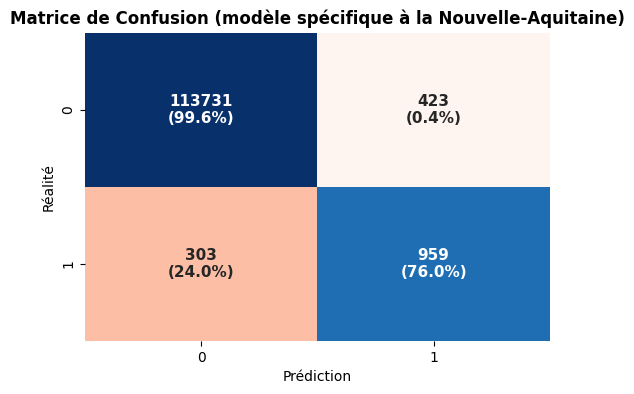

In [103]:
### Création d'une matrice de confusion pour évaluer les prédictions de sécheresse pour la Nouvelle-Aquitaine avec le modèle spécifique ###


# Création de la matrice de confusion
matrice_confusion_nouv_aq = pd.crosstab(
    test_nouv_aq["SECHERESSE"],
    test_nouv_aq["SECHERESSE_PRED_PRUDENT_NA"],
    rownames = ["Vrai"],
    colnames = ["Prédit"]
)

# Calcul des pourcentages dans la matrice de confusion
cm_percent = matrice_confusion_nouv_aq.div(matrice_confusion_nouv_aq.sum(axis=1), axis=0) * 100

# Création des labels (Nombre + %)
labels = (np.asarray(["{0}\n({1:.1f}%)".format(count, pct)
                      for count, pct in zip(matrice_confusion_nouv_aq.values.flatten(),
                                            cm_percent.values.flatten())])
         ).reshape(matrice_confusion_nouv_aq.shape)

# Coloration du graphique avec seaborn

# Masque pour colorer en bleu pour les bonnes réponses (diagonale)
mask_for_blue = np.array([[False, True], 
                          [True, False]])

# Masque pour colorer en rouge pour les erreurs (hors diagonale)
mask_for_red = np.array([[True, False], 
                         [False, True]])

# Création de la figure
plt.figure(figsize = (6, 4))

# Bonnes réponses en bleu (Diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_blue,  # On cache les erreurs
            annot = labels, 
            fmt = "", 
            cmap = "Blues",        # Palette Bleue
            vmin = 0, vmax = 100,    # Échelle 0-100%
            cbar = False,          # Suppression de la barre de couleur
            annot_kws = {"size": 11, "weight": "bold"})

# Mauvaises réponses en rouge (Hors diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_red,   # On cache les bonnes réponses
            annot = labels, 
            fmt = "", 
            cmap = "Reds",         # Palette Rouge
            vmin = 0, vmax = 100, 
            cbar = False, 
            annot_kws = {"size": 11, "weight": "bold"})

plt.title("Matrice de Confusion (modèle spécifique à la Nouvelle-Aquitaine)", fontsize = 12, weight = "bold")
plt.ylabel("Réalité", fontsize = 10)
plt.xlabel("Prédiction", fontsize = 10)

plt.show()

In [104]:
### Calcul de la précision, du rappel et du F2-score pour la Nouvelle-Aquitaine avec le modèle spécifique ###


# Calcul de la précision
precision_nouv_aq_spec = metrics.precision_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT_NA"])

# Calcul du rappel
recall_nouv_aq_spec = metrics.recall_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT_NA"])

# Calcul du F2-score
f2_score_nouv_aq_spec = metrics.fbeta_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT_NA"], beta=2)

# Affichage des résultats
print(f"Précision (Nouvelle-Aquitaine, modèle spécifique) : {precision_nouv_aq_spec:.4f}")
print(f"Rappel (Nouvelle-Aquitaine, modèle spécifique) : {recall_nouv_aq_spec:.4f}")
print(f"F2-score (Nouvelle-Aquitaine, modèle spécifique) : {f2_score_nouv_aq_spec:.4f}")

Précision (Nouvelle-Aquitaine, modèle spécifique) : 0.6939
Rappel (Nouvelle-Aquitaine, modèle spécifique) : 0.7599
F2-score (Nouvelle-Aquitaine, modèle spécifique) : 0.7457


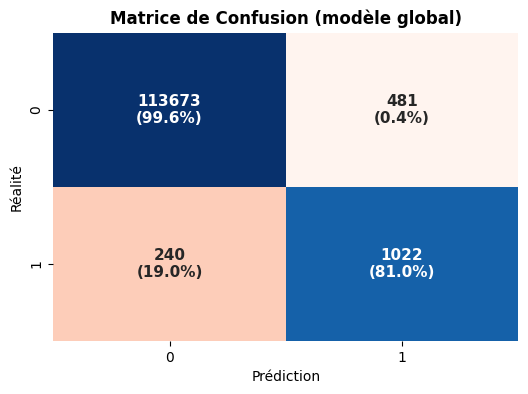

In [105]:
### Création d'une matrice de confusion pour évaluer les prédictions de sécheresse pour la Nouvelle-Aquitaine avec le modèle spécifique ###


# Création de la matrice de confusion
matrice_confusion_nouv_aq = pd.crosstab(
    test_nouv_aq["SECHERESSE"],
    test_nouv_aq["SECHERESSE_PRED_PRUDENT"],
    rownames = ["Vrai"],
    colnames = ["Prédit"]
)

# Calcul des pourcentages dans la matrice de confusion
cm_percent = matrice_confusion_nouv_aq.div(matrice_confusion_nouv_aq.sum(axis=1), axis=0) * 100

# Création des labels (Nombre + %)
labels = (np.asarray(["{0}\n({1:.1f}%)".format(count, pct)
                      for count, pct in zip(matrice_confusion_nouv_aq.values.flatten(),
                                            cm_percent.values.flatten())])
         ).reshape(matrice_confusion_nouv_aq.shape)

# Coloration du graphique avec seaborn

# Masque pour colorer en bleu pour les bonnes réponses (diagonale)
mask_for_blue = np.array([[False, True], 
                          [True, False]])

# Masque pour colorer en rouge pour les erreurs (hors diagonale)
mask_for_red = np.array([[True, False], 
                         [False, True]])

# Création de la figure
plt.figure(figsize = (6, 4))

# Bonnes réponses en bleu (Diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_blue,  # On cache les erreurs
            annot = labels, 
            fmt = "", 
            cmap = "Blues",        # Palette Bleue
            vmin = 0, vmax = 100,    # Échelle 0-100%
            cbar = False,          # Suppression de la barre de couleur
            annot_kws = {"size": 11, "weight": "bold"})

# Mauvaises réponses en rouge (Hors diagonale)
sns.heatmap(cm_percent, 
            mask = mask_for_red,   # On cache les bonnes réponses
            annot = labels, 
            fmt = "", 
            cmap = "Reds",         # Palette Rouge
            vmin = 0, vmax = 100, 
            cbar = False, 
            annot_kws = {"size": 11, "weight": "bold"})

plt.title("Matrice de Confusion (modèle global)", fontsize = 12, weight = "bold")
plt.ylabel("Réalité", fontsize = 10)
plt.xlabel("Prédiction", fontsize = 10)

plt.show()

In [106]:
### Calcul de la précision, du rappel et du F2-score pour la Nouvelle-Aquitaine avec le modèle global ###


# Calcul de la précision
precision_nouv_aq_glob = metrics.precision_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT"])

# Calcul du rappel
recall_nouv_aq_glob = metrics.recall_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT"])

# Calcul du F2-score
f2_score_nouv_aq_glob = metrics.fbeta_score(test_nouv_aq["SECHERESSE"], test_nouv_aq["SECHERESSE_PRED_PRUDENT"], beta=2)

# Affichage des résultats
print(f"Précision (Nouvelle-Aquitaine, modèle global) : {precision_nouv_aq_glob:.4f}")
print(f"Rappel (Nouvelle-Aquitaine, modèle global) : {recall_nouv_aq_glob:.4f}")
print(f"F2-score (Nouvelle-Aquitaine, modèle global) : {f2_score_nouv_aq_glob:.4f}")

Précision (Nouvelle-Aquitaine, modèle global) : 0.6800
Rappel (Nouvelle-Aquitaine, modèle global) : 0.8098
F2-score (Nouvelle-Aquitaine, modèle global) : 0.7800


Le modèle global est meilleur que le modèle spécifique à la Nouvelle-Aquitaine pour la prédiction des événements de sécheresse dans cette région.

### Représentation des événements de sécheresse prédits pour l'été 2024 en Nouvelle-Aquitaine avec la méthode prudente

Nous représentons sur une carte de la Nouvelle-Aquitaine les événements de sécheresse prédits pour l'été 2024 en utilisant la méthode prudente avec un coefficient multiplicateur de 1,20. Les zones en rouge indiquent les régions où une sécheresse est prévue selon notre modèle.

In [107]:
### Ajustement de la base de données pour la carte ###


# Filtrage des données pour l'été 2022 (juillet, août, septembre)
ete_2022 = test_nouv_aq[
    test_nouv_aq["DATE"].isin(["2022-07-01", "2022-08-01", "2022-09-01"])
]

# Variable d'indicatrice d'au moins un épisode de sécheresse réel et prédit durant l'été 2022
presence_secheresse = ete_2022.groupby("NUMERO")[["SECHERESSE", "SECHERESSE_PRED_PRUDENT"]].max().reset_index()

# Géométrie des points
points_geo = test_nouv_aq[["NUMERO", "geometry"]].drop_duplicates()

# Jointure des données de sécheresse avec la géométrie
secheresse_nouv_aq_2022 = points_geo.merge(
    presence_secheresse, 
    on = "NUMERO", 
    how = "left"
)

# Renommage de la colonne et remplissage des valeurs manquantes par 0
secheresse_nouv_aq_2022 = secheresse_nouv_aq_2022.rename(
    columns = {"SECHERESSE": "SECHERESSE_ETE_2022", "SECHERESSE_PRED_PRUDENT": "SECHERESSE_PRED_ETE_2022"}
).fillna(0)

# Affichage de la base
display(secheresse_nouv_aq_2022)

C:\Users\elric\AppData\Local\Temp\ipykernel_8164\3165045952.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ms] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  test_nouv_aq["DATE"].isin(["2022-07-01", "2022-08-01", "2022-09-01"])


,NUMERO,geometry,SECHERESSE_ETE_2022,SECHERESSE_PRED_ETE_2022
0,4493,POINT (387999.539 2232999.653),1,0
1,4494,POINT (395999.203 2232999.458),0,0
2,4495,POINT (403999.866 2232999.322),0,0
3,4497,POINT (419999.186 2232999.18),0,0
4,4498,POINT (427999.845 2232999.192),0,0
...,...,...,...,...
1369,9512,POINT (379997.907 1768996.352),0,1
1370,9553,POINT (355997.312 1760996.66),1,1
1371,9554,POINT (363997.786 1760996.366),1,1
1372,9555,POINT (371998.249 1760997.118),1,1


In [108]:
# Données communes
fp = Path("data") / "raw" / "communes" / "ADE_4-0_GPKG_WGS84G_FRA-ED2025-11-20.gpkg"
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
communes = gpd.read_file(fp, layer='commune')

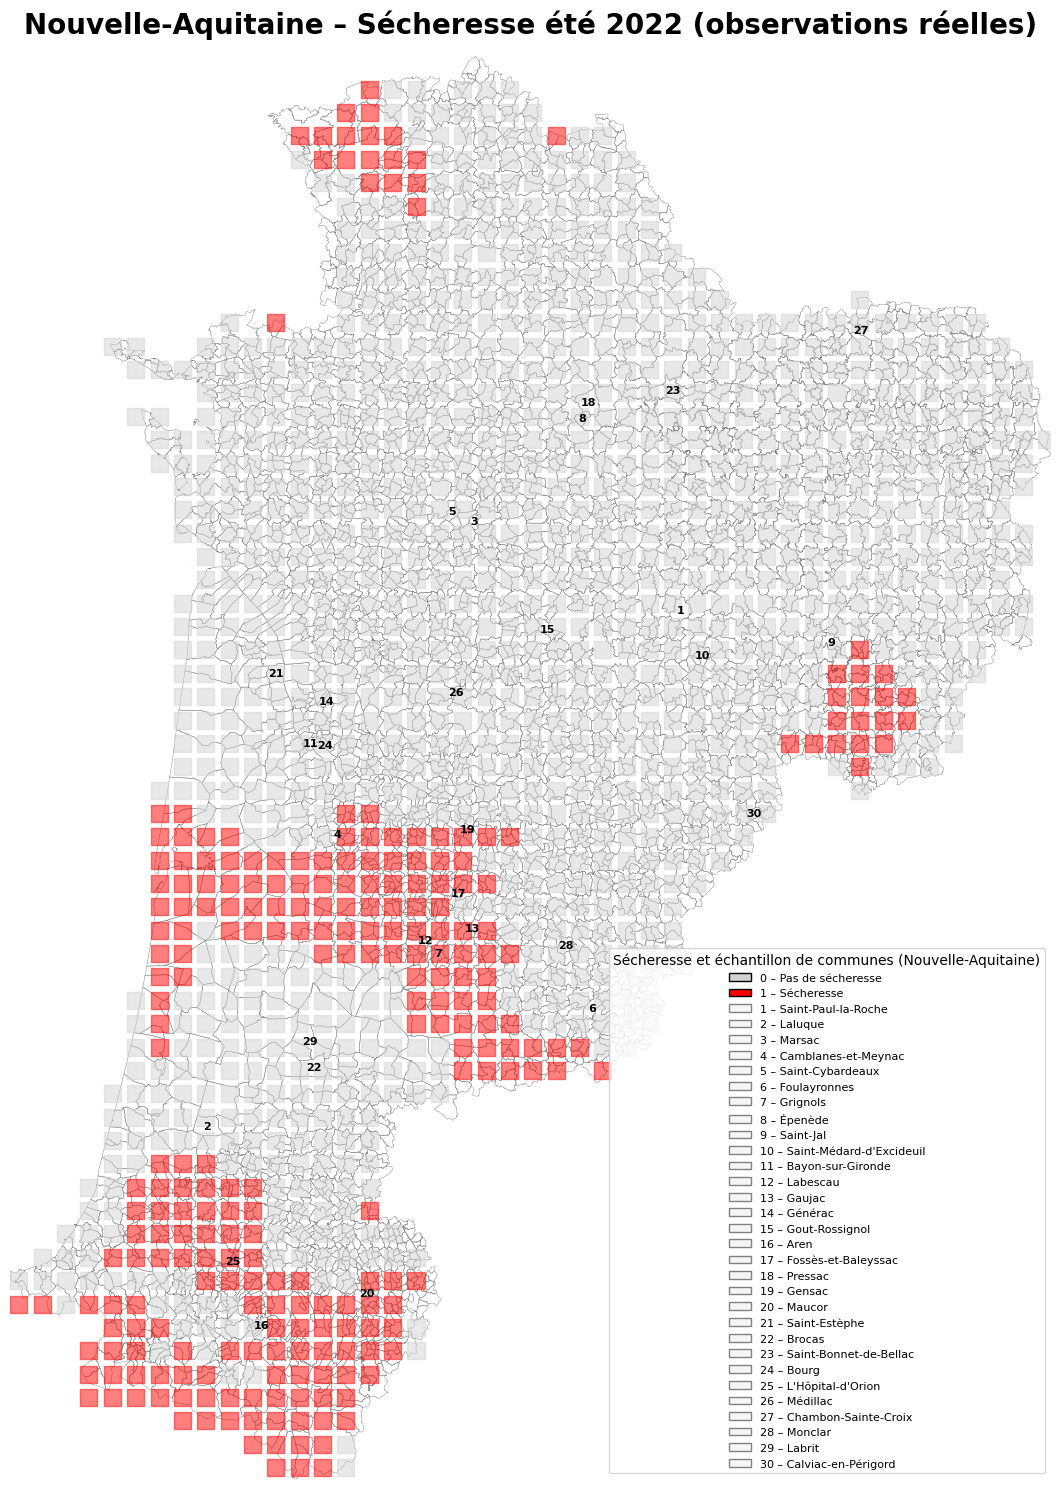

In [109]:
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.pyplot as plt


# Communes Nouvelle-Aquitaine dans le bon CRS
communes_na = communes[
    communes["code_insee_de_la_region"] == "75"
].to_crs(secheresse_nouv_aq_2022.crs)

# Données sécheresse
na_data = secheresse_nouv_aq_2022.copy()

# Échantillon de communes
ech_communes_na = communes_na.sample(30, random_state=0).copy()
ech_communes_na["ID_ECH"] = range(1, len(ech_communes_na) + 1)

# Palette binaire : 0 = pas de sécheresse, 1 = sécheresse
cmap = colors.ListedColormap(["lightgrey", "red"])
bounds = [-0.5, 0.5, 1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(20, 15))

# Fond communes
communes_na.plot(
    ax=ax,
    facecolor="none",
    edgecolor="grey",
    linewidth=0.3,
    zorder=1
)

# Points sécheresse
points = na_data.plot(
    column="SECHERESSE_ETE_2022",
    ax=ax,
    cmap=cmap,
    norm=norm,
    markersize=150,
    alpha=0.5,
    marker="s",
    legend=False,
    zorder=2
)

# Numéros d’échantillon
ech_communes_na["centroid"] = ech_communes_na.geometry.centroid
for x, y, num in zip(
    ech_communes_na["centroid"].x,
    ech_communes_na["centroid"].y,
    ech_communes_na["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        fontweight="bold"
    )

# Légende échantillon
legend_patches = []
for _, row in ech_communes_na.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

# Légende sécheresse (0 / 1) en premier
dry_no = mpatches.Patch(facecolor="lightgrey", edgecolor="black",
                        label="0 – Pas de sécheresse")
dry_yes = mpatches.Patch(facecolor="red", edgecolor="black",
                         label="1 – Sécheresse")

legend_patches = [dry_no, dry_yes]

# Puis l’échantillon de communes
for _, row in ech_communes_na.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Sécheresse et échantillon de communes (Nouvelle-Aquitaine)",
    loc="best",
    fontsize=8,
    frameon=True
)
ax.set_xlim(communes_na.total_bounds[0], communes_na.total_bounds[2])
ax.set_ylim(communes_na.total_bounds[1], communes_na.total_bounds[3])

ax.set_title("Nouvelle-Aquitaine – Sécheresse été 2022 (observations réelles)", fontsize=20, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


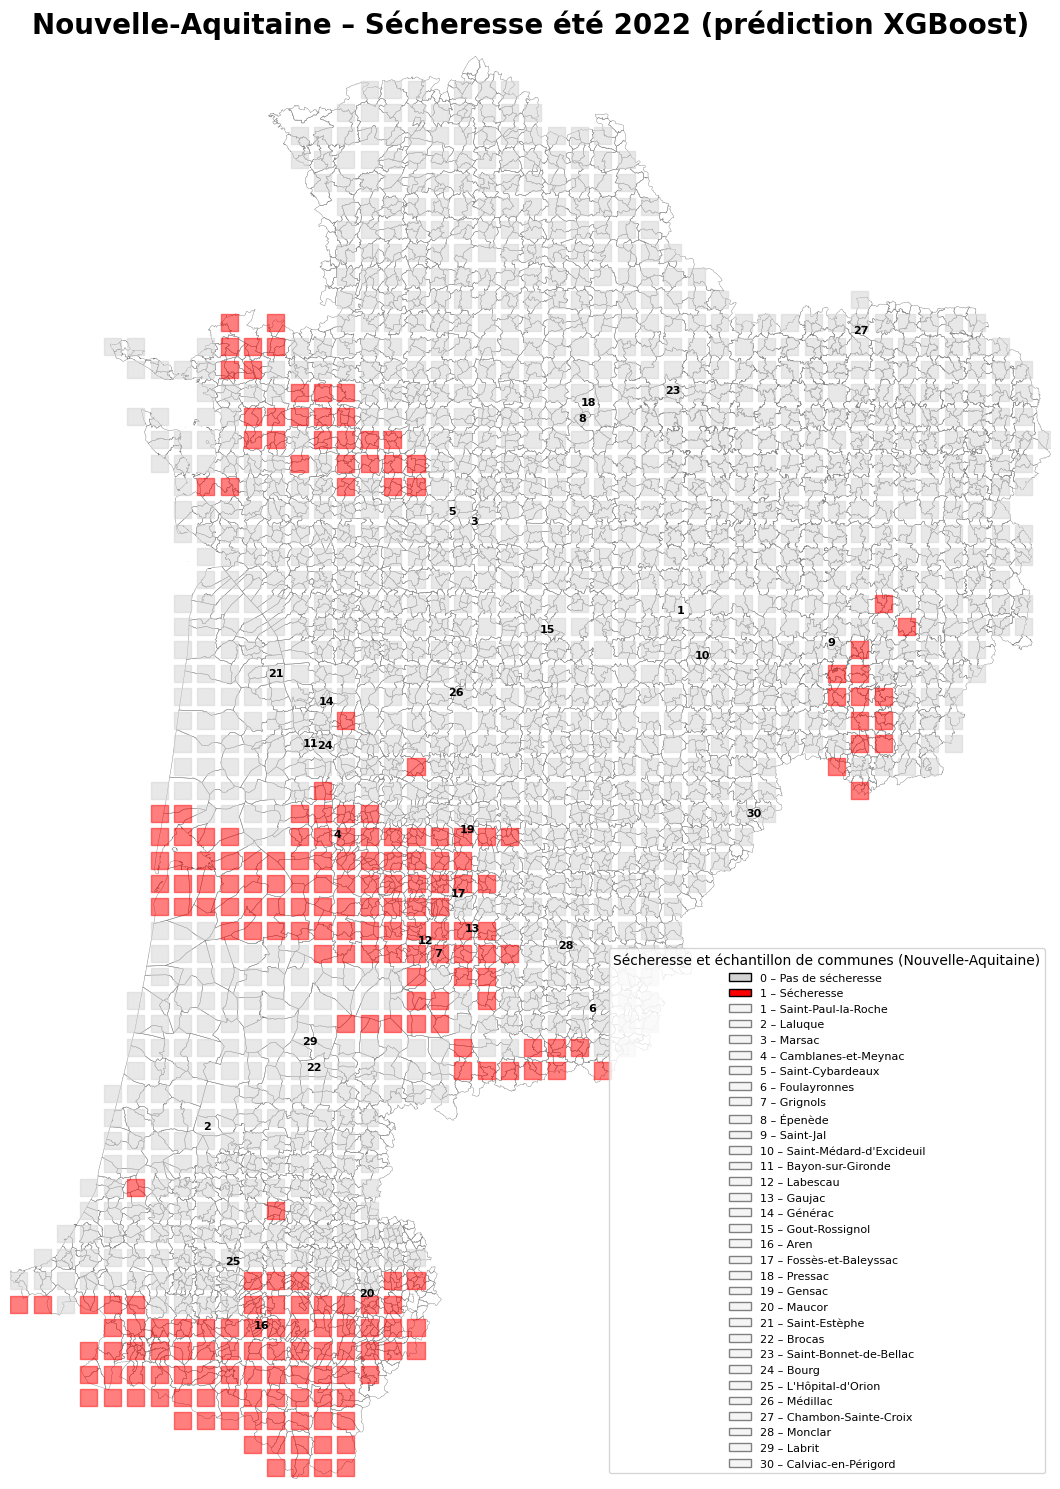

In [110]:
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.pyplot as plt


# Communes Nouvelle-Aquitaine dans le bon CRS
communes_na = communes[
    communes["code_insee_de_la_region"] == "75"
].to_crs(secheresse_nouv_aq_2022.crs)

# Données sécheresse
na_data = secheresse_nouv_aq_2022.copy()

# Échantillon de communes
ech_communes_na = communes_na.sample(30, random_state=0).copy()
ech_communes_na["ID_ECH"] = range(1, len(ech_communes_na) + 1)

# Palette binaire : 0 = pas de sécheresse, 1 = sécheresse
cmap = colors.ListedColormap(["lightgrey", "red"])
bounds = [-0.5, 0.5, 1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(20, 15))

# Fond communes
communes_na.plot(
    ax=ax,
    facecolor="none",
    edgecolor="grey",
    linewidth=0.3,
    zorder=1
)

# Points sécheresse
points = na_data.plot(
    column="SECHERESSE_PRED_ETE_2022",
    ax=ax,
    cmap=cmap,
    norm=norm,
    markersize=150,
    alpha=0.5,
    marker="s",
    legend=False,
    zorder=2
)

# Numéros d’échantillon
ech_communes_na["centroid"] = ech_communes_na.geometry.centroid
for x, y, num in zip(
    ech_communes_na["centroid"].x,
    ech_communes_na["centroid"].y,
    ech_communes_na["ID_ECH"]
):
    ax.text(
        x, y, str(num),
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        fontweight="bold"
    )

# Légende échantillon
legend_patches = []
for _, row in ech_communes_na.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

# Légende sécheresse (0 / 1) en premier
dry_no = mpatches.Patch(facecolor="lightgrey", edgecolor="black",
                        label="0 – Pas de sécheresse")
dry_yes = mpatches.Patch(facecolor="red", edgecolor="black",
                         label="1 – Sécheresse")

legend_patches = [dry_no, dry_yes]

# Puis l’échantillon de communes
for _, row in ech_communes_na.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(
        facecolor="whitesmoke",
        edgecolor="grey",
        label=label
    )
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Sécheresse et échantillon de communes (Nouvelle-Aquitaine)",
    loc="best",
    fontsize=8,
    frameon=True
)
ax.set_xlim(communes_na.total_bounds[0], communes_na.total_bounds[2])
ax.set_ylim(communes_na.total_bounds[1], communes_na.total_bounds[3])

ax.set_title("Nouvelle-Aquitaine – Sécheresse été 2022 (prédiction XGBoost)", fontsize=20, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


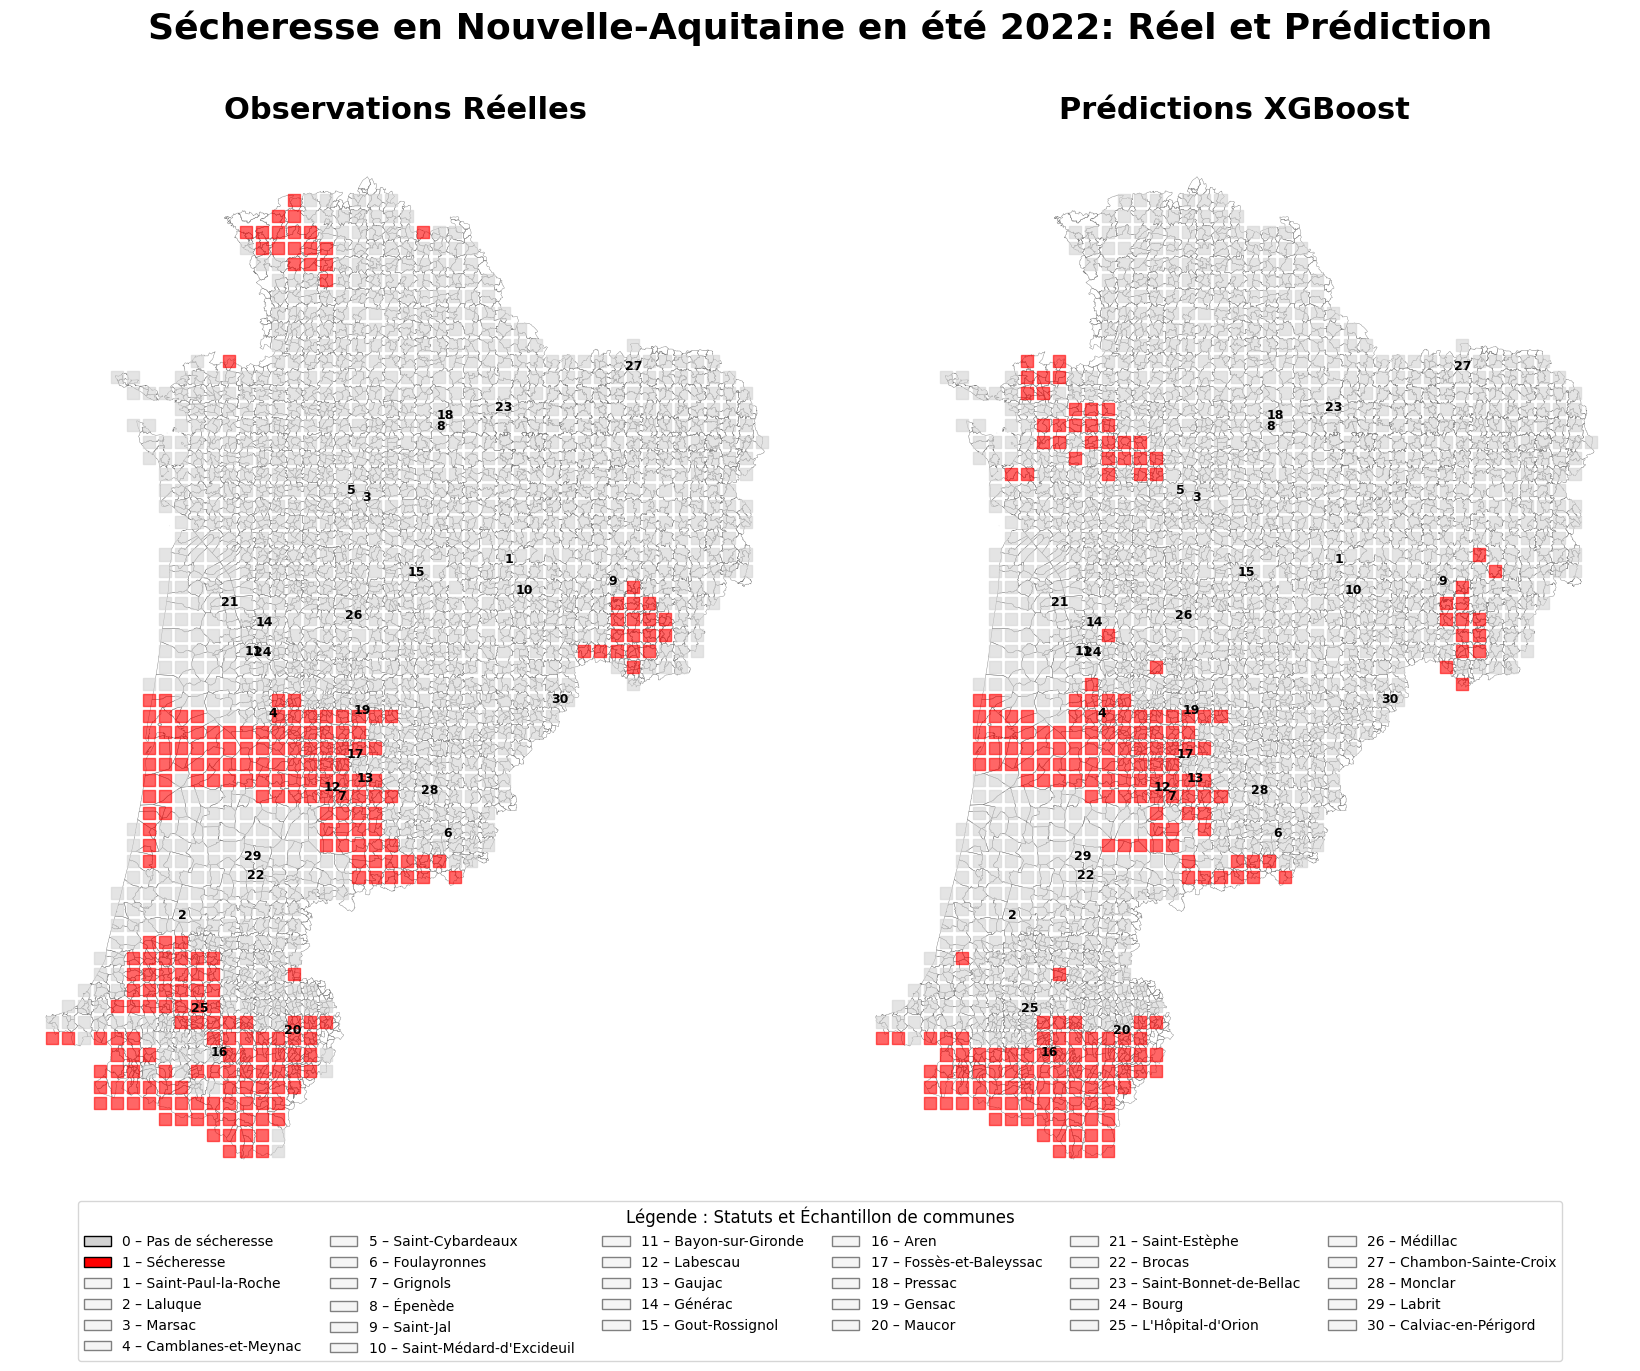

In [125]:
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.pyplot as plt


# Préparation : paramètres graphiques
cmap = colors.ListedColormap(["lightgrey", "red"])
bounds = [-0.5, 0.5, 1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Légende
dry_no = mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="0 – Pas de sécheresse")
dry_yes = mpatches.Patch(facecolor="red", edgecolor="black", label="1 – Sécheresse")
legend_patches = [dry_no, dry_yes]

# Echantillon de communes
for _, row in ech_communes_na.iterrows():
    label = f"{row['ID_ECH']} – {row['nom_officiel']}"
    patch = mpatches.Patch(facecolor="whitesmoke", edgecolor="grey", label=label)
    legend_patches.append(patch)

# Création de la figure avec 2 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Préparation des configurations pour chaque sous-graphique
configs = [
    {"ax": axes[0], "col": "SECHERESSE_ETE_2022", "title": "Observations Réelles"},
    {"ax": axes[1], "col": "SECHERESSE_PRED_ETE_2022", "title": "Prédictions XGBoost"}
]

# Boucle pour chaque sous-graphique
for config in configs:
    ax = config["ax"]
    
    # Fond de carte
    communes_na.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.3, zorder=1)
    
    # Données
    na_data.plot(
        column=config["col"], ax=ax, cmap=cmap, norm=norm,
        markersize=75, alpha=0.6, marker="s", legend=False, zorder=2
    )

    # Numéros
    for x, y, num in zip(ech_communes_na["centroid"].x, ech_communes_na["centroid"].y, ech_communes_na["ID_ECH"]):
        ax.text(x, y, str(num), fontsize=9, ha="center", va="center", color="black", fontweight="bold", zorder=3)

    # Titre de l'axe
    ax.set_title(config["title"], fontsize=22, fontweight="bold", pad=6)
    ax.set_axis_off()

# Titre global
fig.suptitle("Sécheresse en Nouvelle-Aquitaine en été 2022: Réel et Prédiction", fontsize=26, fontweight="bold", y=0.98)

# Légende
fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01), # Colle au bas de l'image
    ncol=6,
    fontsize=10,
    title="Légende : Statuts et Échantillon de communes",
    title_fontsize=12,
    frameon=True,
    fancybox=True
)

# Ajustement des marges pour un meilleur rendu
plt.subplots_adjust(top=0.9, bottom=0.12, wspace=0.05, left=0.05, right=0.95)

# Affichage
plt.show()